# Descriptive Analysis - U.S. Amazon Revenue Analytics



- **Dataset**: [Open e-commerce 1.0: Five years of crowdsourced U.S. Amazon purchase histories with user demographics](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/YGLYDY)

- **Article**: [Link to the Article](https://www.nature.com/articles/s41597-024-03329-6)

      1. The paper introduced and validated the dataset rather than answering our specific business questions.
      2. It used external comparisons such as Amazon sales, Census retail sales, COVID trends, migration, and CPI to show that the data are credible.
      3. Our project uses the published data independently for a descriptive business-analytics use case: analysing observed spending by product category, customer segment, geography, and time.

> ### This project independently applies descriptive business analytics to the published data.

## Business Problem


How do demographic factors like age, income, education constitute the highest-value customers and which geographic locations (on a state level) drive customer value and dictate regional product demand, among U.S. Amazon customers in this study sample?
Are there regional variations in product category preferences across U.S. states?


## Objectives

    - Analyze sales performance and customer behaviour based on demography
    - Identify top-selling products in different geographic locations (and high-value customers)
    - Examine relationships between quantity, pricing and revenue

## Proposed Analysis

- Sales trend analysis
- Product and customer analysis
- Revenue analysis

## Analysis Roadmap

### Data Integration
- [x] Import relevant libraries
- [x] Load `amazon-purchases.csv` and `survey.csv` into DataFrames


### Data Cleaning and Preprocessing

- [x] Type Casting, Missing Values, Outliers
- [x] **Data Integration**: Merge the purchase data with the demographic data on the `Survey ResponseID` key to create a master dataset.
- [x] Data Reduction, Transformation


### Preliminary Analysis (Summary Statistics)
- [x] High level view of data using `.describe()` and `.info()`
- [x] Extract interesting metrics

### Exploratory Data Analysis

- [x] **Univariate Analysis**:
    - Distribution of `Total Price`
    - Frequency counts for `Category`, `Agg_Category`, `Q-demos-age`, `Q-demos-income`, `Q-demos-state`
- [x] **Multivariate Analysis**:
    - Revenue distribution by `Income Group`
    - Revenue distribution by `Age Group`
    - Revenue distribution by `State` (`Q-demos-state`)
    - Monthly Revenue Trends
    - Daily Revenue Patterns by `Day of Week`


### Summary and Results
- [x] Present the results using visualizations (`matplotlib`).
Bar plots (seaborn), histograms, line graphs have been used, In time patterns matplotlib is used*
- [x] Derive business insishgts from descriptive patterns and correlations.
- [x] Create Dashboard from findings


### Research Questions
1. What are the customer's spending trends over time?
Monthly and yearly spending patterns
    
2. Which product categories generate the most revenue?
Top categories by total spend
    
3. Which categories are purchased most frequently?
Top categories by number of orders
    
4. Are purchases concentrated in a few categories or spread across many?
Using category share chart
    
5. Are there unusual high-value purchases?
Identifying outliers

    Which product categories in which state should be recommended?

### Use cases


- Improve inventory planning
- Target profitable customer groups
- Optimize product offerings
- Increase overall revenue

### Future Expected Outcome (Predictive Analysis) :
***Predict a high-value customer***:

    Can we classify whether a customer will be a high-value customer?     



---



## Discussion

We could also add another preprocessed Dataset including a mapping between the ISBN codes and the book categories. The dataset is available here:
https://github.com/aberke/amazon-study/blob/master/data-analysis/preprocessed/google_books_api_isbn_category.csv

# Data Integration

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# The datasets need to be placed in a directory called 'Business Analytics' on Google Drive. Arrange it according your files location on Google Drive

# drive_directory = '/content/drive/MyDrive/Business Analytics'

drive_directory = '/content/drive/MyDrive/Business Analytics'

amzn_purchases_csv = os.path.join(drive_directory, 'amazon-purchases.csv')
survey_csv = os.path.join(drive_directory, 'survey.csv')

# Save the DataFrame to CSV
amzn_data = pd.read_csv(amzn_purchases_csv)
survey_data = pd.read_csv(survey_csv)


Mounted at /content/drive


# Data Cleaning and Preprocessing

In [ ]:
# Merge Data
data = pd.merge(amzn_data, survey_data, left_on='Survey ResponseID', right_on='Survey ResponseID')

In [ ]:
# List of columns to be removed
columns_to_remove = [
    'Q-substance-use-cigarettes',
    'Q-substance-use-marijuana',
    'Q-substance-use-alcohol',
    'Q-personal-diabetes',
    'Q-demos-race',
    'Q-amazon-use-howmany',
    'Q-amazon-use-hh-size',
    'Q-personal-wheelchair',
    'Q-life-changes',
    'Q-sell-YOUR-data',
    'Q-sell-consumer-data',
    'Q-small-biz-use',
    'Q-census-use',
    'Q-research-society',
    'Q-sexual-orientation'
]

# Drop the specified columns
data = data.drop(columns=columns_to_remove, errors='ignore')

In [ ]:
# Type Casting and Data Cleaning
# Convert 'Order Date' to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')

# Convert 'Purchase Price Per Unit' and 'Quantity' to numeric
data['Purchase Price Per Unit'] = pd.to_numeric(data['Purchase Price Per Unit'], errors='coerce')
data['Quantity'] = pd.to_numeric(data['Quantity'], errors='coerce')

# Convert 'Q-demos-hispanic' to boolean
data['Q-demos-hispanic'] = (
    data['Q-demos-hispanic']
    .astype(str)
    .str.lower()
    .str.strip()
    .map({'yes': True, 'no': False})
    .astype('boolean')
)

# Convert other columns to categories
for col in ['Shipping Address State', 'Category','Q-demos-age', 'Q-demos-education', 'Q-demos-income', 'Q-demos-gender', "Q-demos-state", 'Q-amazon-use-how-oft']:
    data[col] = data[col].astype('category')

print("DEBUG: Data types after initial conversion:")
display(data.info())

DEBUG: Data types after initial conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 15 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   Order Date                datetime64[ns]
 1   Purchase Price Per Unit   float64       
 2   Quantity                  float64       
 3   Shipping Address State    category      
 4   Title                     object        
 5   ASIN/ISBN (Product Code)  object        
 6   Category                  category      
 7   Survey ResponseID         object        
 8   Q-demos-age               category      
 9   Q-demos-hispanic          boolean       
 10  Q-demos-education         category      
 11  Q-demos-income            category      
 12  Q-demos-gender            category      
 13  Q-demos-state             category      
 14  Q-amazon-use-how-oft      category      
dtypes: boolean(1), category(8), datetime64[ns](1), float64(2

None

### Data Transformations

We will perform the following transformations:

1.  **Extract Date Components**: Create new columns for year, month, and day of the week from the 'Order Date' column.
2.  **Calculate Total Price**: Create a 'Total Price' column by multiplying 'Purchase Price Per Unit' and 'Quantity'.
3. **Aggregate Categories**: Create an 'Agg_Category' column by trying to classify our default categories with known search terms

In [ ]:
# Extract date components
data['Order Year'] = data['Order Date'].dt.year
data['Order Month'] = data['Order Date'].dt.month
data['Order DayOfWeek'] = data['Order Date'].dt.dayofweek # Monday=0, Sunday=6

# Calculate Total Price
data['Total Price'] = data['Purchase Price Per Unit'] * data['Quantity']

print("DataFrame after adding 'Order Year', 'Order Month', 'Order DayOfWeek', and 'Total Price' columns:")
display(data.head())

DataFrame after adding 'Order Year', 'Order Month', 'Order DayOfWeek', and 'Total Price' columns:


,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,Q-demos-age,Q-demos-hispanic,Q-demos-education,Q-demos-income,Q-demos-gender,Q-demos-state,Q-amazon-use-how-oft,Order Year,Order Month,Order DayOfWeek,Total Price
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF,35 - 44 years,True,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,1,7.98
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF,35 - 44 years,True,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,5,13.99
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF,35 - 44 years,True,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,0,8.99
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF,35 - 44 years,True,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,1,10.45
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF,35 - 44 years,True,Bachelor's degree,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,1,10.00


In [ ]:
# Aggregate Category data into more generic groups and add them to another column

# Load a map of predefined General-Categories identified by search (sub-)strings
mapping_df = pd.read_csv(os.path.join(drive_directory, 'category_map.csv'))

conditions = []
choices = []

# Build the rule set
for index, row in mapping_df.iterrows():
  # Create the search condition (case-insensitive, ignore nan)
  condition = data['Category'].str.contains(row['SEARCH_STRINGS'], case=False, na=False)
  conditions.append(condition)
  choices.append(row['NEW_CATEGORY'])

# Apply the rules and
data['Agg_Category'] = np.select(conditions, choices, default='Other / Misc')
data['Agg_Category'] = data['Agg_Category'].astype('category')
print(data['Agg_Category'].value_counts())


# Extract distinct 'Category' fields from the 'Other / Misc' group for inspection of missed out groups
misc_data = data[data['Agg_Category'] == 'Other / Misc']
unique_misc_categories = misc_data['Category'].dropna().unique()
unique_misc_categories_df = pd.DataFrame(unique_misc_categories, columns=['Category'])
unique_misc_categories_df.to_csv('unique_misc_categories.csv', index=False)
print("unique_misc_categories.csv has been saved for inspection.")

Agg_Category
Other / Misc               574165
Groceries & Food           219287
Clothing & Apparel         162405
Electronics & Cables       116208
Books & Media               95498
Health & Supplements        86627
Pet Supplies                83410
Skincare & Beauty           76179
Toys & Games                69672
Home & Furniture            54148
Household Cleaning          47999
Office & School             45410
Tools & Hardware            43706
Personal Care & Hygiene     42107
Gift Cards                  36753
Automotive                  27940
Crafts & Hobbies            25039
Kitchen & Dining            15296
Outdoor & Garden            14178
Sports & Fitness            12664
Baby & Toddler               2026
Name: count, dtype: int64
unique_misc_categories.csv has been saved for inspection.


In [ ]:
print("Info after transformations:")
display(data.info())

Info after transformations:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 20 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   Order Date                datetime64[ns]
 1   Purchase Price Per Unit   float64       
 2   Quantity                  float64       
 3   Shipping Address State    category      
 4   Title                     object        
 5   ASIN/ISBN (Product Code)  object        
 6   Category                  category      
 7   Survey ResponseID         object        
 8   Q-demos-age               category      
 9   Q-demos-hispanic          boolean       
 10  Q-demos-education         category      
 11  Q-demos-income            category      
 12  Q-demos-gender            category      
 13  Q-demos-state             category      
 14  Q-amazon-use-how-oft      category      
 15  Order Year                int32         
 16  Order Month               

None

# Analytical Scope and Data Quality Decision

The raw cleaned purchase file contains observations dated from January 2018 to August 2024. However, date auditing found that post-2022 coverage is incomplete: most later records occur in 2023, while only one record appears in 2024.



In [ ]:
data['Order_Value'] = data['Purchase Price Per Unit'] * data['Quantity']

# by year
year_audit = data.groupby('Order Year').agg(
    Purchase_Records=('Survey ResponseID', 'size'),
    Unique_Customers=('Survey ResponseID', 'nunique'),
    Non_Missing_Price=('Purchase Price Per Unit', 'count'),
    Non_Missing_Quantity=('Quantity', 'count'),
    Total_Recorded_Value=('Order_Value', 'sum'),
    Minimum_Date=('Order Date', 'min'),
    Maximum_Date=('Order Date', 'max')
).reset_index()

display(year_audit)

print("Overall earliest date:", data['Order Date'].min())
print("Overall latest date:", data['Order Date'].max())

,Order Year,Purchase_Records,Unique_Customers,Non_Missing_Price,Non_Missing_Quantity,Total_Recorded_Value,Minimum_Date,Maximum_Date
0,2018,225465,4281,225465,225465,5505384.55,2018-01-01,2018-12-31
1,2019,266016,4520,266016,266016,6435336.67,2019-01-01,2019-12-31
2,2020,409212,4723,409212,409212,9338033.52,2020-01-01,2020-12-31
3,2021,467870,4862,467870,467870,11120069.65,2021-01-01,2021-12-31
4,2022,442230,4868,442230,442230,10726805.37,2022-01-01,2022-12-31
5,2023,39923,2173,39923,39923,928001.52,2023-01-01,2023-09-01
6,2024,1,1,1,1,1.84,2024-08-15,2024-08-15


Overall earliest date: 2018-01-01 00:00:00
Overall latest date: 2024-08-15 00:00:00


To ensure comparable full-year descriptive statistics, valid time trends, and a consistent basis for predictive analysis, the main analytical dataset is restricted to complete years from 1 January 2018 to 31 December 2022.

The raw cleaned data are retained separately for transparency.

In [ ]:
# cleaned records
data_raw = data.copy()

# analytical time window
analysis_start = pd.Timestamp("2018-01-01")
analysis_end = pd.Timestamp("2022-12-31")

# dataset to be used
data = data_raw[
    (data_raw["Order Date"] >= analysis_start) &
    (data_raw["Order Date"] <= analysis_end)
].copy()

# time variables after filtering
data["Order Year"] = data["Order Date"].dt.year
data["Order Month"] = data["Order Date"].dt.month
data["Order DayOfWeek"] = data["Order Date"].dt.dayofweek

print("Raw Cleaned Data")
print("Rows:", len(data_raw))
print("Date range:", data_raw["Order Date"].min(), "to", data_raw["Order Date"].max())

print("\nAnalytical Data to be used")
print("Rows:", len(data))
print("Date range:", data["Order Date"].min(), "to", data["Order Date"].max())

print("\nExcluded incomplete post-2022 records:", len(data_raw) - len(data))

Raw Cleaned Data
Rows: 1850717
Date range: 2018-01-01 00:00:00 to 2024-08-15 00:00:00

Analytical Data to be used
Rows: 1810793
Date range: 2018-01-01 00:00:00 to 2022-12-31 00:00:00

Excluded incomplete post-2022 records: 39924


# Preliminary Analysis (Summary Statistics)

In [ ]:
# Missing value info
#print("Missing values per column:")
#display(data.isnull().sum())

print("Shape before dropping NA values in 'Category':", data.shape)
rows_before_drop = data.shape[0]

# Remove Missing values from 'Category' since this information will be used for the main analysis
data = data.dropna(subset=['Category'])

rows_after_drop = data.shape[0]
rows_deleted = rows_before_drop - rows_after_drop

print("Shape after dropping NA values in 'Category':", data.shape)
print(f"Number of rows deleted due to missing 'Category' values: {rows_deleted}")

# Everything else can stay since Title, since those are not important for analysis
# In the case of 'Shipping Address State' we can just use 'Q-demos-state' which has no missing values
# But we should make sure that this can be used for correlating the datat
# Note: If we decide to create a Category to ISBN mapping (see Discussion) we could drop those as well

print("\nMissing values after elimination:")
display(data.isnull().sum())

Shape before dropping NA values in 'Category': (1810793, 21)
Shape after dropping NA values in 'Category': (1721558, 21)
Number of rows deleted due to missing 'Category' values: 89235

Missing values after elimination:


,0
Order Date,0
Purchase Price Per Unit,0
Quantity,0
Shipping Address State,83443
Title,873
ASIN/ISBN (Product Code),573
Category,0
Survey ResponseID,0
Q-demos-age,0
Q-demos-hispanic,0


- [x] **Shape before dropping NA values in `Category`: *(1810793, 21)***

- [x] **Number of rows deleted due to missing `Category` values: *89235***

- [x] **Shape after dropping NA values in `Category`: *(1721558, 21)***

> **Number of rows used for analysis is thereby *1721558*, which is our total order volume now.**



In [ ]:
# Inspect data

print("=== ALL DATA TYPES ===")
print(data.columns)
print("\n")

print("=== CATEGORIES ===")
for col in data.select_dtypes(include=['category']).columns:
  print(data[col].value_counts(dropna=False))
  print("\n")

print(data['Q-demos-hispanic'].value_counts(dropna=False))


# Save categories to csv to make inspecting easier.
category_counts = data['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
category_counts.to_csv('category_counts.csv', index=False)

print("q_demos_hispanic_counts.csv has been saved.")

# To inspect categories in code we can use one of the following access functions
# Using the .cat.categories attribute
# display(data['Category'].cat.categories)

# Using the .unique() method
# display(data['Category'].unique())

=== ALL DATA TYPES ===
Index(['Order Date', 'Purchase Price Per Unit', 'Quantity',
       'Shipping Address State', 'Title', 'ASIN/ISBN (Product Code)',
       'Category', 'Survey ResponseID', 'Q-demos-age', 'Q-demos-hispanic',
       'Q-demos-education', 'Q-demos-income', 'Q-demos-gender',
       'Q-demos-state', 'Q-amazon-use-how-oft', 'Order Year', 'Order Month',
       'Order DayOfWeek', 'Total Price', 'Agg_Category', 'Order_Value'],
      dtype='object')


=== CATEGORIES ===
Shipping Address State
CA     166002
TX     126367
FL     102804
NY      96536
PA      90447
NaN     83443
OH      80747
IL      66737
NC      65705
MI      56071
WA      49809
GA      49540
VA      47406
NJ      42830
MA      41510
IN      40758
WI      34467
OR      33811
TN      32599
MD      31202
AZ      30983
MN      27408
CO      27203
KY      25053
NV      19570
LA      18737
SC      18039
MO      17004
AL      16851
CT      16074
OK      15941
KS      14020
AR      13330
UT      12732
NE      11712
MS

In [ ]:
print("=== OVERALL DATA SUMMARY")
display(data.info())

# Disable scientific notation for displaying the data
pd.set_option('display.float_format', lambda x: '%.2f' % x)

display(data.select_dtypes(include=['int64', 'float64', 'datetime64']).describe())
display(data.select_dtypes(include=['category', 'boolean', 'object']).describe())

# Alternatively display all columns
# display(data.describe(include='all'))

# Enable scientific notation again
pd.reset_option('display.float_format')

print("\n First rows:")
display(data.head())


=== OVERALL DATA SUMMARY
<class 'pandas.core.frame.DataFrame'>
Index: 1721558 entries, 0 to 1850716
Data columns (total 21 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   Order Date                datetime64[ns]
 1   Purchase Price Per Unit   float64       
 2   Quantity                  float64       
 3   Shipping Address State    category      
 4   Title                     object        
 5   ASIN/ISBN (Product Code)  object        
 6   Category                  category      
 7   Survey ResponseID         object        
 8   Q-demos-age               category      
 9   Q-demos-hispanic          boolean       
 10  Q-demos-education         category      
 11  Q-demos-income            category      
 12  Q-demos-gender            category      
 13  Q-demos-state             category      
 14  Q-amazon-use-how-oft      category      
 15  Order Year                int32         
 16  Order Month               int32   

None

,Order Date,Purchase Price Per Unit,Quantity,Total Price,Order_Value
count,1721558,1721558.00,1721558.00,1721558.00,1721558.00
mean,2020-12-01 04:30:08.073850368,22.55,1.09,23.70,23.70
min,2018-01-01 00:00:00,0.01,1.00,0.01,0.01
25%,2019-12-14 00:00:00,8.27,1.00,8.85,8.85
50%,2021-01-24 00:00:00,13.99,1.00,14.49,14.49
75%,2022-01-06 00:00:00,23.36,1.00,24.80,24.80
max,2022-12-31 00:00:00,6398.95,339.00,6398.95,6398.95
std,NaN,45.62,0.79,48.95,48.95


,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,Q-demos-age,Q-demos-hispanic,Q-demos-education,Q-demos-income,Q-demos-gender,Q-demos-state,Q-amazon-use-how-oft,Agg_Category
count,1638115,1720685,1720985,1721558,1721558,1721558,1721558,1721558,1721558,1721558,1721558,1721558,1721558
unique,52,808909,859706,1871,5024,6,2,5,7,4,52,3,21
top,CA,Amazon.com Gift Card Balance Reload,B00IX1I3G6,ABIS_BOOK,R_8CXcySQawXPuJwJ,25 - 34 years,False,Bachelor's degree,"$100,000 - $149,999",Female,California,5 - 10 times per month,Other / Misc
freq,166002,11373,11373,86265,4790,546944,1559517,772418,362344,1000483,178639,720083,473727



 First rows:


,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,Q-demos-age,Q-demos-hispanic,...,Q-demos-income,Q-demos-gender,Q-demos-state,Q-amazon-use-how-oft,Order Year,Order Month,Order DayOfWeek,Total Price,Agg_Category,Order_Value
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF,35 - 44 years,True,...,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,1,7.98,Electronics & Cables,7.98
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF,35 - 44 years,True,...,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,5,13.99,Electronics & Cables,13.99
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF,35 - 44 years,True,...,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,1,10.45,Kitchen & Dining,10.45
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF,35 - 44 years,True,...,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2018,12,1,10.00,Personal Care & Hygiene,10.00
5,2019-02-18,10.99,1.0,NJ,Micro USB Cable Android Charger - Syncwire [2-...,B01GFB2E9M,COMPUTER_PROCESSOR,R_01vNIayewjIIKMF,35 - 44 years,True,...,"$25,000 - $49,999",Male,New Jersey,Less than 5 times per month,2019,2,0,10.99,Electronics & Cables,10.99


### Aggregated Views

May add more of those based on analysis needs

In [ ]:
# Aggregate total sales by Category
sales_by_category = data.groupby('Category')['Total Price'].sum().sort_values(ascending=False)
print("         Top 10 Categories by Total Sales:")
display(sales_by_category.head(10))

         Top 10 Categories by Total Sales:


/tmp/ipykernel_2456/2069365141.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_category = data.groupby('Category')['Total Price'].sum().sort_values(ascending=False)


,Total Price
Category,
ABIS_BOOK,1337049.86
GIFT_CARD,887639.45
PET_FOOD,752841.51
NUTRITIONAL_SUPPLEMENT,604105.18
NOTEBOOK_COMPUTER,578418.88
SHOES,562050.29
HEADPHONES,535391.15
SHIRT,504363.13
PANTS,397926.69


In [ ]:
# Aggregate total sales by Shipping Address State
sales_by_state = data.groupby('Shipping Address State')['Total Price'].sum().sort_values(ascending=False)
print("Top 10 States by Total Sales:")
display(sales_by_state.head(10))

Top 10 States by Total Sales:


/tmp/ipykernel_2456/360507915.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_state = data.groupby('Shipping Address State')['Total Price'].sum().sort_values(ascending=False)


,Total Price
Shipping Address State,
CA,4018227.04
TX,3006862.16
FL,2467465.62
NY,2196463.34
PA,2047251.81
OH,1828703.25
IL,1605814.01
NC,1539808.65
MI,1294621.79


In [ ]:
# Aggregate total sales by Q-demos-income
sales_by_income = data.groupby('Q-demos-income')['Total Price'].sum().sort_values(ascending=False)
print("Total Sales by Income Level:")
display(sales_by_income)

Total Sales by Income Level:


/tmp/ipykernel_2456/461935238.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_income = data.groupby('Q-demos-income')['Total Price'].sum().sort_values(ascending=False)


,Total Price
Q-demos-income,
"$100,000 - $149,999",8930564.12
"$50,000 - $74,999",8051373.40
"$25,000 - $49,999",7185127.39
"$75,000 - $99,999",6705727.51
"$150,000 or more",6145919.10
"Less than $25,000",3418175.80
Prefer not to say,371537.74




---



# Exploratory Data Analysis and Descriptive Statistics

Now, here we explore the cleaned and merged Amazon purchase and survey dataset. We find the descriptive patterns that help us tackle the business problem we defined and also explain the customers types' and product categories' which are contributing in the Amazon revenues.

**Initial data exploration**

In [ ]:
data_shape = data.shape # dimensions (rows, columns) of data
column_names = data.columns.tolist() # all column names in data as a list
missing_values = data.isnull().sum().sort_values(ascending=False).head(15) # top 15 columns with the most missing values in data ; no. of missing values for each column
duplicate_rows_count = data.duplicated().sum() # total number of duplicate rows in data
data_types = data.dtypes # data type for each column

print(f"\nShape: {data_shape}")
print(f"\nColumns:\n {column_names}")
print(f"\nMissing values (top 15):\n {missing_values}\nQ-demos-state has no missing values and can be used for correlating data. Q-demos-state is sufficient for our geographic analysis. Thus, we consider the missing Shipping Address State less critical.")
print(f"\nDuplicate rows: {duplicate_rows_count}")
print(f"\nData types:\n {data_types} \ndata is in the correct format for analysis")


Shape: (1721558, 21)

Columns:
 ['Order Date', 'Purchase Price Per Unit', 'Quantity', 'Shipping Address State', 'Title', 'ASIN/ISBN (Product Code)', 'Category', 'Survey ResponseID', 'Q-demos-age', 'Q-demos-hispanic', 'Q-demos-education', 'Q-demos-income', 'Q-demos-gender', 'Q-demos-state', 'Q-amazon-use-how-oft', 'Order Year', 'Order Month', 'Order DayOfWeek', 'Total Price', 'Agg_Category', 'Order_Value']

Missing values (top 15):
 Shipping Address State      83443
Title                         873
ASIN/ISBN (Product Code)      573
Quantity                        0
Order Date                      0
Purchase Price Per Unit         0
Category                        0
Survey ResponseID               0
Q-demos-age                     0
Q-demos-hispanic                0
Q-demos-education               0
Q-demos-income                  0
Q-demos-gender                  0
Q-demos-state                   0
Q-amazon-use-how-oft            0
dtype: int64
Q-demos-state has no missing values and 

**Duplicate-looking purchase rows were retained** because repeated product purchases may represent legitimate separate transactions.

**The available data do not provide a reliable basket-level order identifier** that would allow all duplicate-looking records to be classified confidently as errors.

> **Dataset is already well prepared for analysis**, with key variables for time, revenue, category, geography, and demographics.

**Descriptive Statistics for Numerical Variables**

We see now the statistical summary for numerical features like `Purchase Price Per Unit`, `Quantity`, `Total Price`, `Order Year`, and `Order Month`.

In [ ]:
display(data[["Purchase Price Per Unit", "Quantity", "Total Price", "Order Year", "Order Month"]].describe())

,Purchase Price Per Unit,Quantity,Total Price,Order Year,Order Month
count,1.721558e+06,1.721558e+06,1.721558e+06,1.721558e+06,1.721558e+06
mean,2.255370e+01,1.089901e+00,2.370436e+01,2.020392e+03,6.834713e+00
std,4.562236e+01,7.935260e-01,4.894561e+01,1.317156e+00,3.480983e+00
min,1.000000e-02,1.000000e+00,1.000000e-02,2.018000e+03,1.000000e+00
25%,8.270000e+00,1.000000e+00,8.850000e+00,2.019000e+03,4.000000e+00
50%,1.399000e+01,1.000000e+00,1.449000e+01,2.021000e+03,7.000000e+00
75%,2.336000e+01,1.000000e+00,2.480000e+01,2.022000e+03,1.000000e+01
max,6.398950e+03,3.390000e+02,6.398950e+03,2.022000e+03,1.200000e+01


**Value Counts for Categorical Variables**

So, let's check now the distribution of categorical variables:- top 10 most frequent values each category. We get to know the dominant products, their categories and customer demographics.

In [ ]:
amz_cols = ["Category", "Agg_Category", "Q-demos-age", "Q-demos-income", "Q-demos-gender", "Q-demos-state", "Q-amazon-use-how-oft"]

for col in amz_cols:
    print(f"\n    {col} (Top 10 Values) ") # selecting the top 10 most frequent values and their counts.
    display(data[col].value_counts().head(10)) # For each categorical column, counting the occurrences of each unique value.


    Category (Top 10 Values) 


,count
Category,
ABIS_BOOK,86265
PET_FOOD,37315
GIFT_CARD,27341
SHIRT,26765
NUTRITIONAL_SUPPLEMENT,26137
ELECTRONIC_CABLE,17895
HEALTH_PERSONAL_CARE,16358
MEDICATION,15648
PANTS,15554



    Agg_Category (Top 10 Values) 


,count
Agg_Category,
Other / Misc,473727
Groceries & Food,213870
Clothing & Apparel,158906
Electronics & Cables,113697
Books & Media,93990
Health & Supplements,84304
Pet Supplies,81451
Skincare & Beauty,74192
Toys & Games,68506



    Q-demos-age (Top 10 Values) 


...

,count
Q-demos-gender,
Female,1000483
Male,688882
Other,30928
Prefer not to say,1265



    Q-demos-state (Top 10 Values) 


,count
Q-demos-state,
California,178639
Texas,129922
Florida,106619
New York,98314
Pennsylvania,96080
Ohio,82412
Illinois,72155
North Carolina,72012
Michigan,56994



    Q-amazon-use-how-oft (Top 10 Values) 


,count
Q-amazon-use-how-oft,
5 - 10 times per month,720083
Less than 5 times per month,650646
More than 10 times per month,350829



---



##Revenue distribution
**Histogram to visualize the distribution of the Total Price in our dataset**

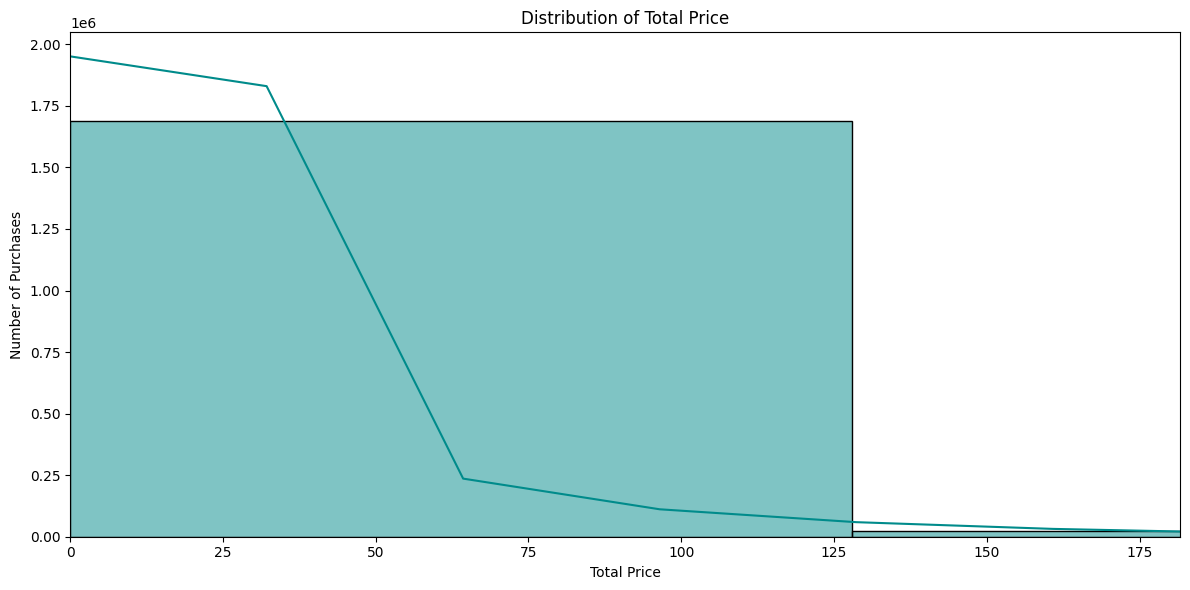

In [ ]:
plt.figure(figsize=(12, 6)) # figure is 12 inches wide and 6 inches tall
sns.histplot(data["Total Price"], bins=50, kde=True, color="darkcyan")# Plotting Total Price from our data
# 50 equal intervals for the Total Price and no. of purchases in each one ; KDE curve in the histogram giving continuous view
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Number of Purchases") # the frequency count for each price bin
plt.xlim(0, data["Total Price"].quantile(0.99))
# 99% percentile will show 99% of our data-> distribution clearer and no large outliers.
plt.tight_layout()
plt.show()




*   The plot's x-axis (Total Price) is indeed showing values up to around $175. This is to show only the transactions up to the 99th percentile of Total Price.
* Products costing thousands of dollars are present in our data, but they are outliers, and here our plot focuses on the bulk/most of the purchases.
*   We see 1e6 on the y-axis. So, the highest no. of purchases in our graph is two million.
*   The highest bar in the histogram- large number of purchases around approx. 1.75 million are those of products costing low.



**This chart shows** that *most purchases have low total values*, while a small number of very large orders stretch the distribution to the right. That means *revenue is skewed*, so the business should pay attention to high-value transactions rather than only average purchase size.

**The reason**- Focusing purely on the average would be misleading because those few large orders contribute disproportionately to the total revenue.

**Now, check here the Main distribution while still acknowledging outliers**, *which also by the way confirms that high-value transactions exist but the vast majority of purchases are for lower amounts* :-

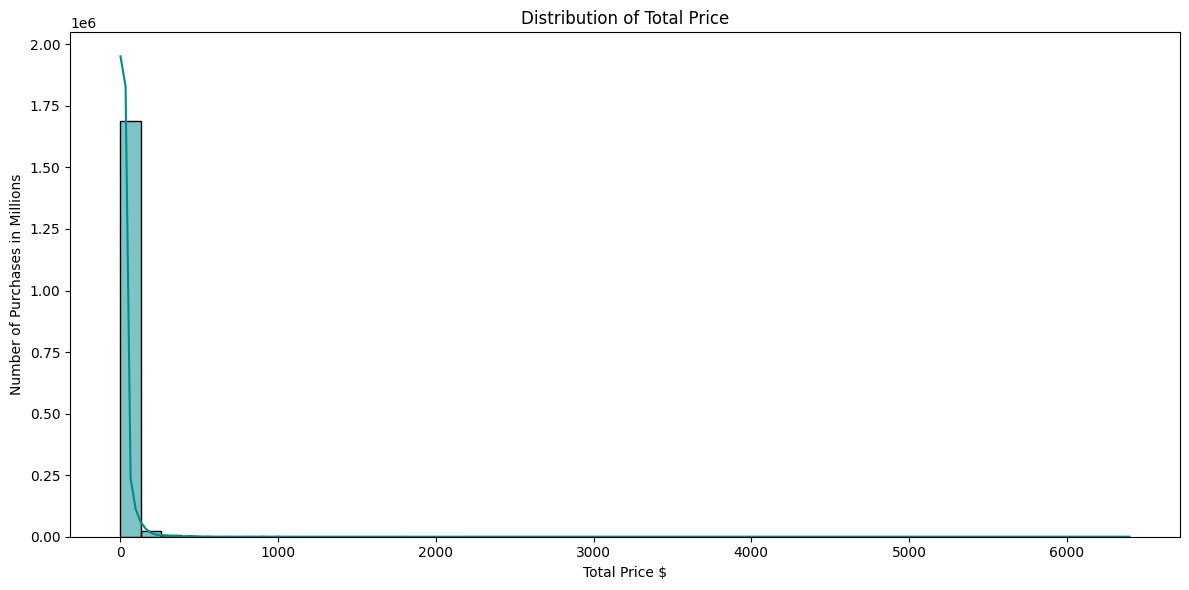

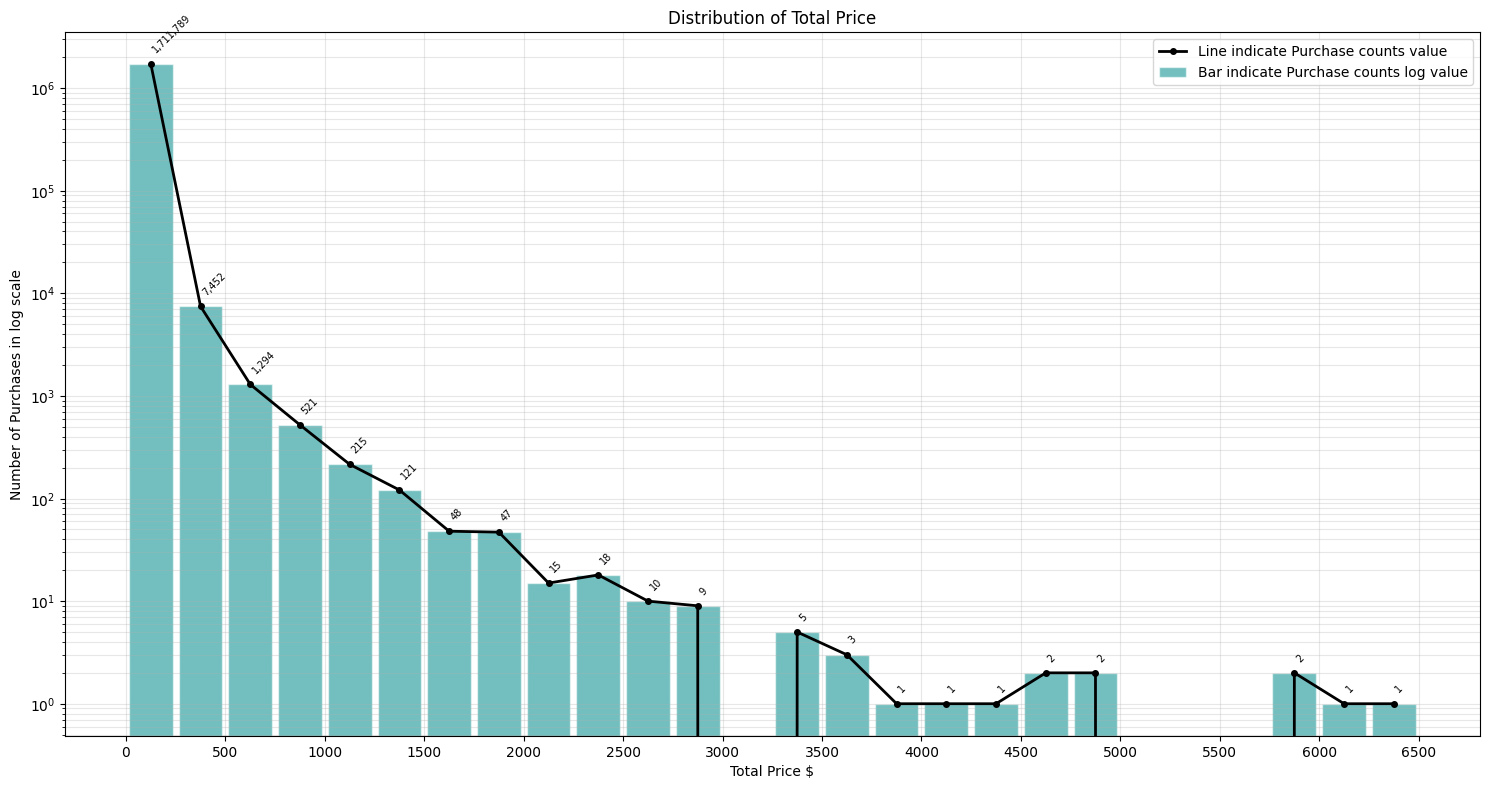

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data["Total Price"], bins=50, kde=True, color="darkcyan")
plt.title("Distribution of Total Price")
plt.xlabel("Total Price $")
plt.ylabel("Number of Purchases in Millions")


plt.tight_layout()
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# price range bins: $250 buckets
bin_edges = np.arange(0, data["Total Price"].max() + 250, 250)
counts, edges = np.histogram(data["Total Price"], bins=bin_edges)
bin_centers = (edges[:-1] + edges[1:]) / 2

fig, ax = plt.subplots(figsize=(15, 8))

# Bars : counts per $250 bucket
ax.bar(bin_centers, counts, width=220, color="darkcyan", alpha=0.55,
       edgecolor="white", label="Bar indicate Purchase counts log value")

# Line :  connecting the bar tops
ax.plot(bin_centers, counts, color="black", linewidth=2, marker="o",
        markersize=4, label="Line indicate Purchase counts value")

# Log scale y-axis : low counts at high prices -> visible
ax.set_yscale("log")
ax.set_xticks(np.arange(0, data["Total Price"].max() + 500, 500))
ax.set_xlabel("Total Price $")
ax.set_ylabel("Number of Purchases in log scale")
ax.set_title("Distribution of Total Price")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

#  non-zero bars numbered (label), overlap reduced by offset
for c, ct in zip(bin_centers, counts):
    if ct > 0:
        ax.annotate(f"{ct:,}", (c, ct), textcoords="offset points",
                    xytext=(0, 8), fontsize=7, rotation=45, ha="left")

plt.tight_layout()
plt.show()



---



##Top categories by purchase count

**We now see bar plot to visualize the top 10 most frequently purchased product categories in our dataset.**

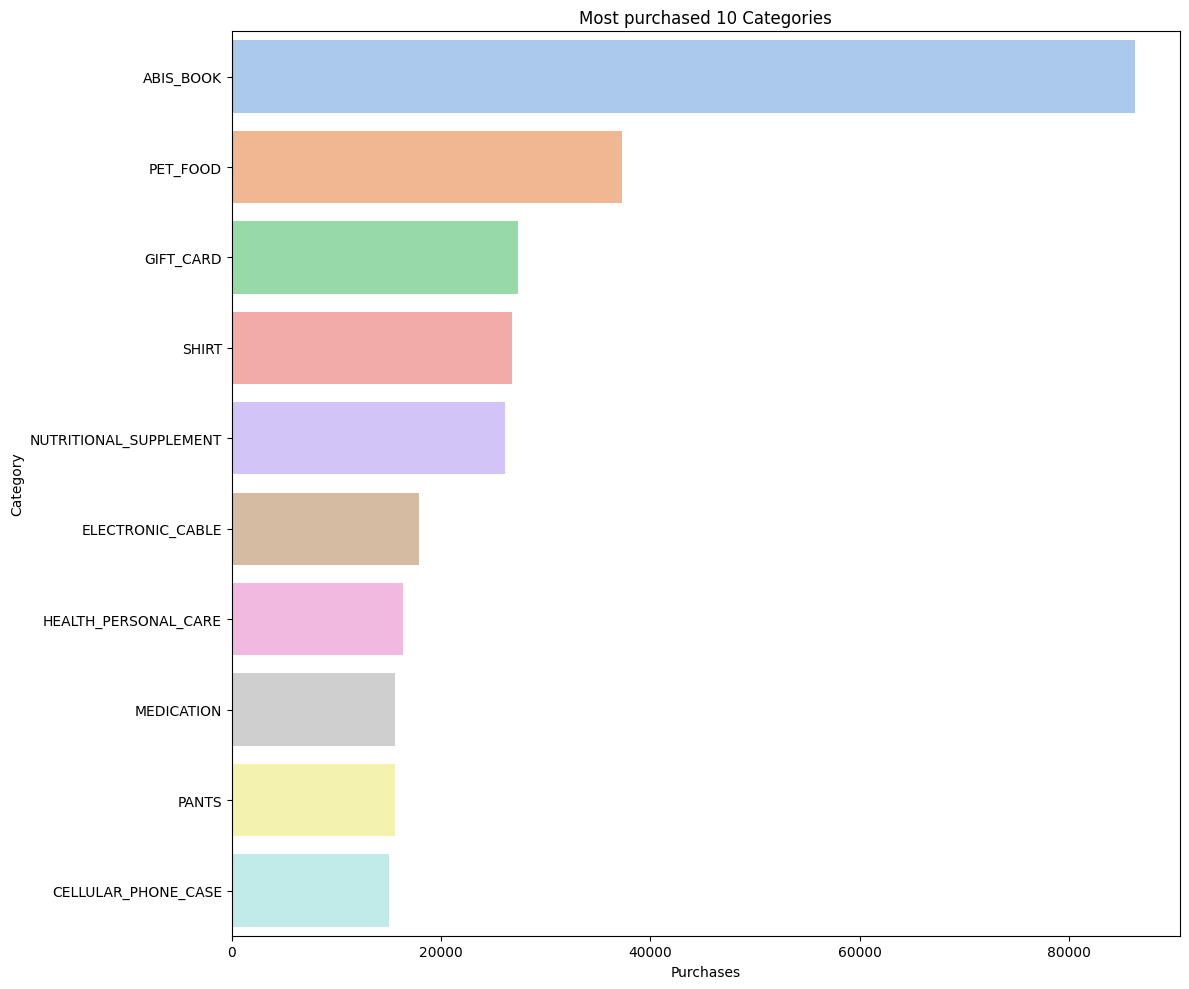

In [ ]:
top_amz_count = data["Category"].value_counts().head(10)

plt.figure(figsize=(12, 10))
sns.barplot(
    x=top_amz_count.values,
    y=top_amz_count.index.astype(str),
    palette="pastel",
    hue=top_amz_count.index.astype(str),
    legend=False
)
#  x-axis=counts of purchases for each category. y-axis=names of the categories
plt.title("Most purchased 10 Categories")
plt.xlabel("Purchases")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

The `Category` column used for above **bar plot** has long and numerous *category names which overlap* and thus may not represent correct and unique information about top purchases.


1.   We created `Agg_Category` column in **data preparation** phase- to *group similar* `Category` names into more concise categories.
2.   This *helps analyzing top categories and greatly reduce label overlap*



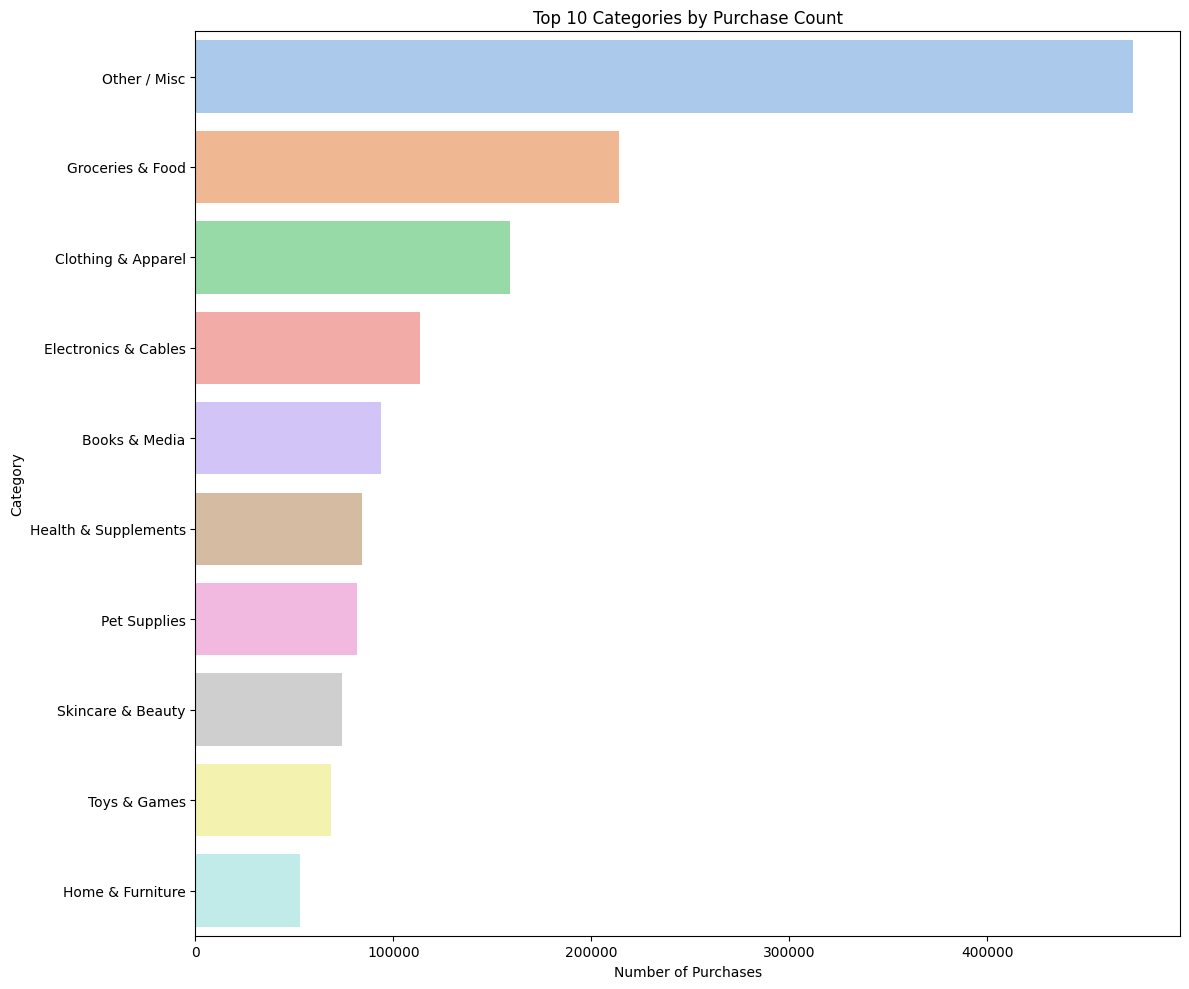

In [ ]:
top_amz_count = data["Agg_Category"].value_counts().head(10)

plt.figure(figsize=(12, 10))
sns.barplot(
    x=top_amz_count.values,
    y=top_amz_count.index.astype(str),
    palette="pastel",
    hue=top_amz_count.index.astype(str),
    legend=False
)

#  x-axis represents the counts of purchases for each category. y-axis display the names of the categories
plt.title("Top 10 Categories by Purchase Count")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


> ### Other / Misc is a residual category created by our keyword-based mapping; it is useful for reducing chart complexity but should not be interpreted as a coherent customer-demand segment.

This chart shows which categories appear most often in customer purchases. These are likely the most visible categories in customer behavior and should be prioritized in stock planning, merchandising, and promotions.


In [ ]:
# Checking the largest 'Other / Misc' aggregated category
unique_misc_categories_counts_df = data[data['Agg_Category'] == 'Other / Misc']['Category'].value_counts()

print("       No. of purchases of Top 10 categories in 'Other / Misc'")
display(unique_misc_categories_counts_df.head(10))

       No. of purchases of Top 10 categories in 'Other / Misc'


,count
Category,
ELECTRONIC_CABLE,17895
PHYSICAL_MOVIE,6844
SHORTS,6176
ABIS_MUSIC,5189
STICKER_DECAL,5158
LIGHT_BULB,4923
ADHESIVE_TAPES,4894
SAFETY_MASK,4840
INCONTINENCE_PROTECTOR,4808


Lets us see more **insights** from the **graph** above:-


*   Firstly, the **largest category is '*Other / Misc*'**. Many diverse and less frequent categories are grouped into it, thereby artificially increasing count.
*   Thus, for our consideration-  **'*Groceries & Food*' is the highest sold category** with over 200k ourchases.





---



##Demographic patterns



1.   **Revenue by Income group**
2.   **Revenue by Age group**
3.   **Revenue by State**



### Revenue by Income group

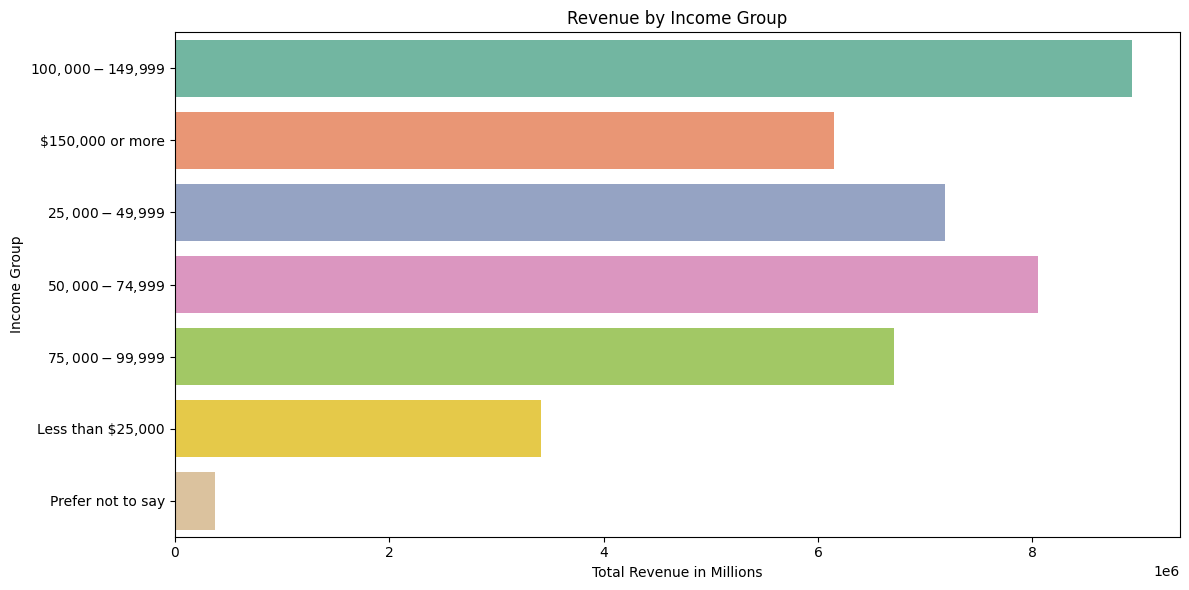

In [ ]:
rev_incom = data.groupby("Q-demos-income", observed=True)["Total Price"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=rev_incom.values, y=rev_incom.index, palette="Set2", hue=rev_incom.index, legend=False)
plt.title("Revenue by Income Group")
plt.xlabel("Total Revenue in Millions")
plt.ylabel("Income Group")
plt.tight_layout()
plt.show() # 1e6 = 1 * 10^6

This **chart shows** *revenue distribution* across income groups. It tells us whether higher-income or lower-income customers contribute more spending, which is useful for promotions basis- *income segmentations*.


*   The **highest revenue** is generated from the group **100k - 150k** (excluding) = more than 8 million



#### **Product Categories for Highest Revenue Income Group**

Let's analyze which product categories are most popular within the income group that generates the highest revenue. This can help in targeted marketing and product development strategies for this high-value segment.

/tmp/ipykernel_2456/869225488.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_cat_highest_income.values, y=product_cat_highest_income.index, palette='viridis', legend=False)


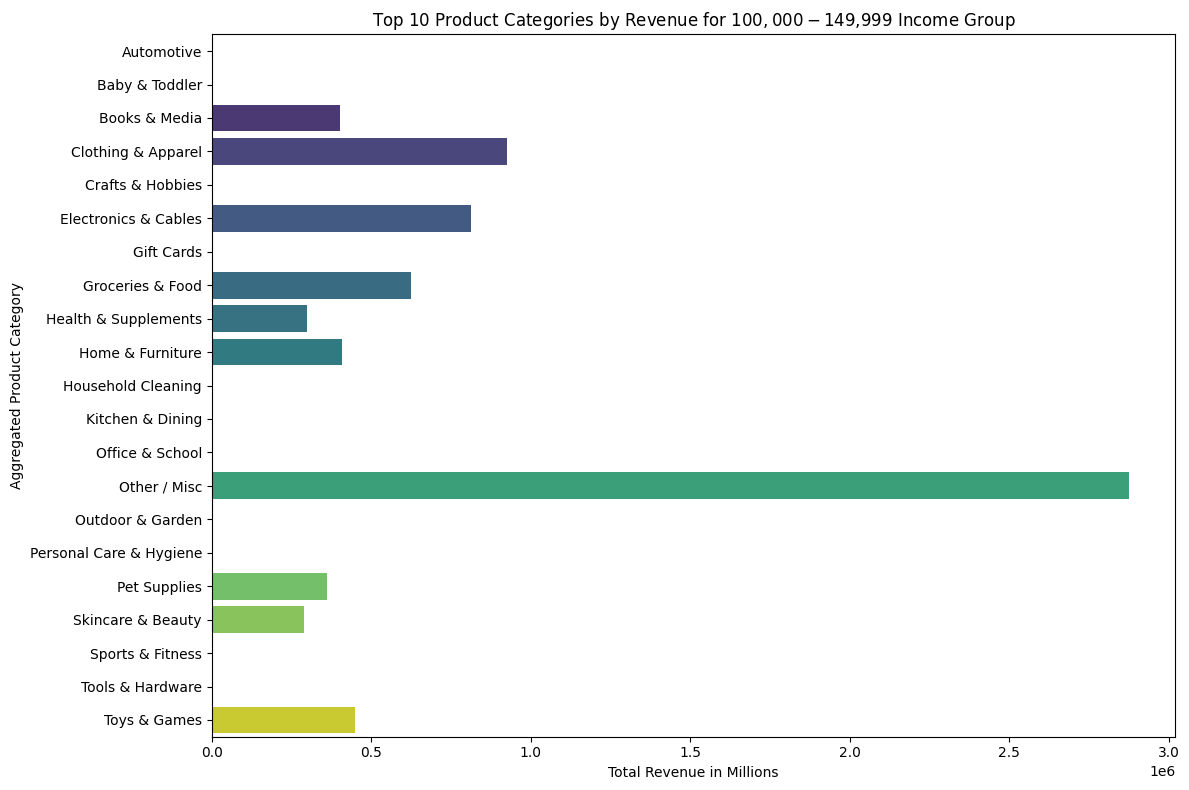


--- Refined View for $100,000 - $149,999 ---


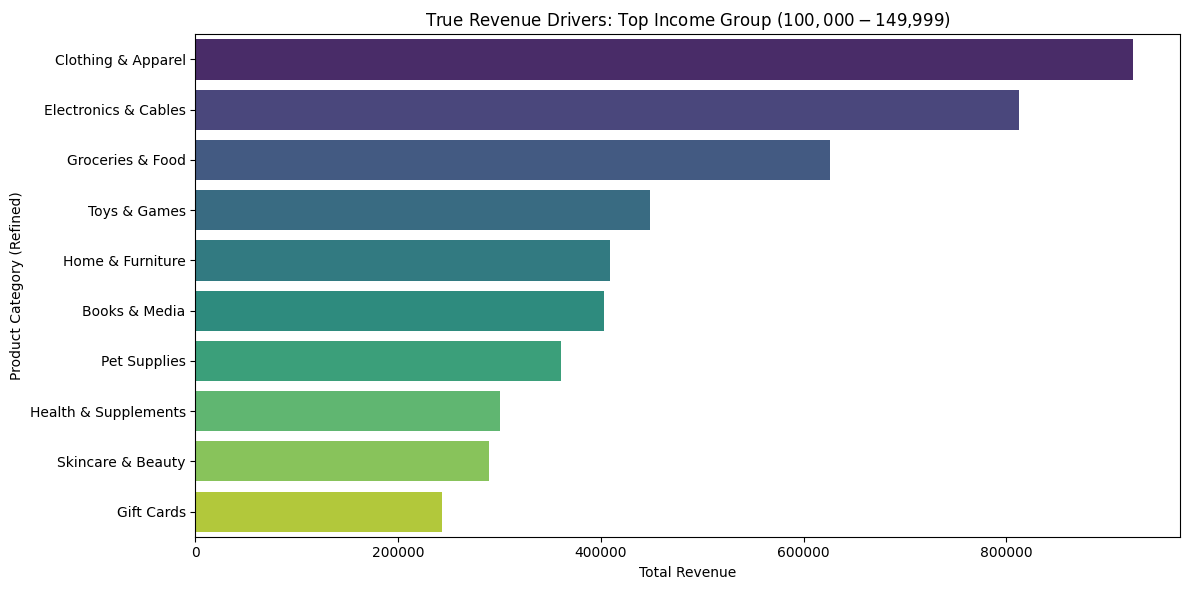

In [ ]:
highest_rev_income_group = rev_incom.index[0]

data_highest_income = data[data['Q-demos-income'] == highest_rev_income_group]

product_cat_highest_income = data_highest_income.groupby('Agg_Category', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=product_cat_highest_income.values, y=product_cat_highest_income.index, palette='viridis', legend=False)
plt.title(f'Top 10 Product Categories by Revenue for {highest_rev_income_group} Income Group')
plt.xlabel('Total Revenue in Millions')
plt.ylabel('Aggregated Product Category')
plt.tight_layout()
plt.show()

print(f"\n--- Refined View for {highest_rev_income_group} ---")
plot_refined_analysis(data_highest_income, f'Top Income Group ({highest_rev_income_group})')

> - [x] **Clothing and Apparel is the most revenue generating product category in the age group 100,000 to 149,999**

###Revenue by Age group

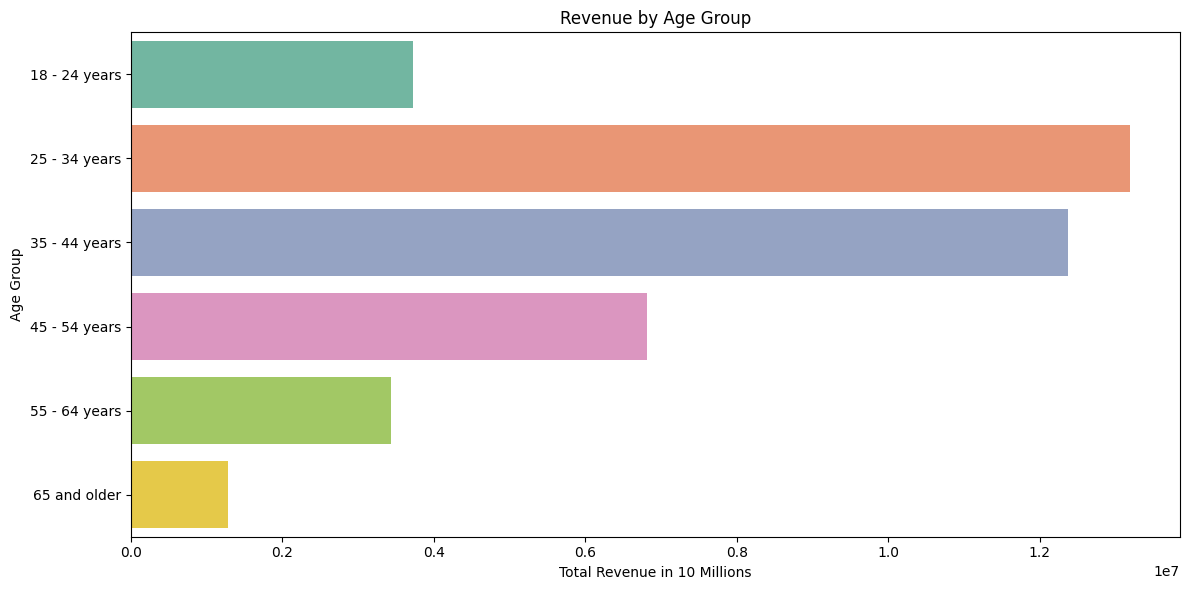

In [ ]:
age_wise_rev = data.groupby("Q-demos-age", observed=True)["Total Price"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=age_wise_rev.values, y=age_wise_rev.index, palette="Set2", hue=age_wise_rev.index, legend=False)
plt.title("Revenue by Age Group")
plt.xlabel("Total Revenue in 10 Millions")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show() # 1e7 is 1 * 10^7

This **chart shows** which **age groups** contribute the most revenue. **Age-based segmenting** during promotions and can help match *product recommendations* and also put pricing more effectively.


*   The **age goup 25 to 34 years** generate *most revenue*, more than around **13 million**.



#### **Income Groups and Product Categories for Highest Revenue Age Group**

Now, let's drill down into the age group that generates the most revenue to understand their income distribution and preferred product categories. This provides a more nuanced view for age-specific targeting.

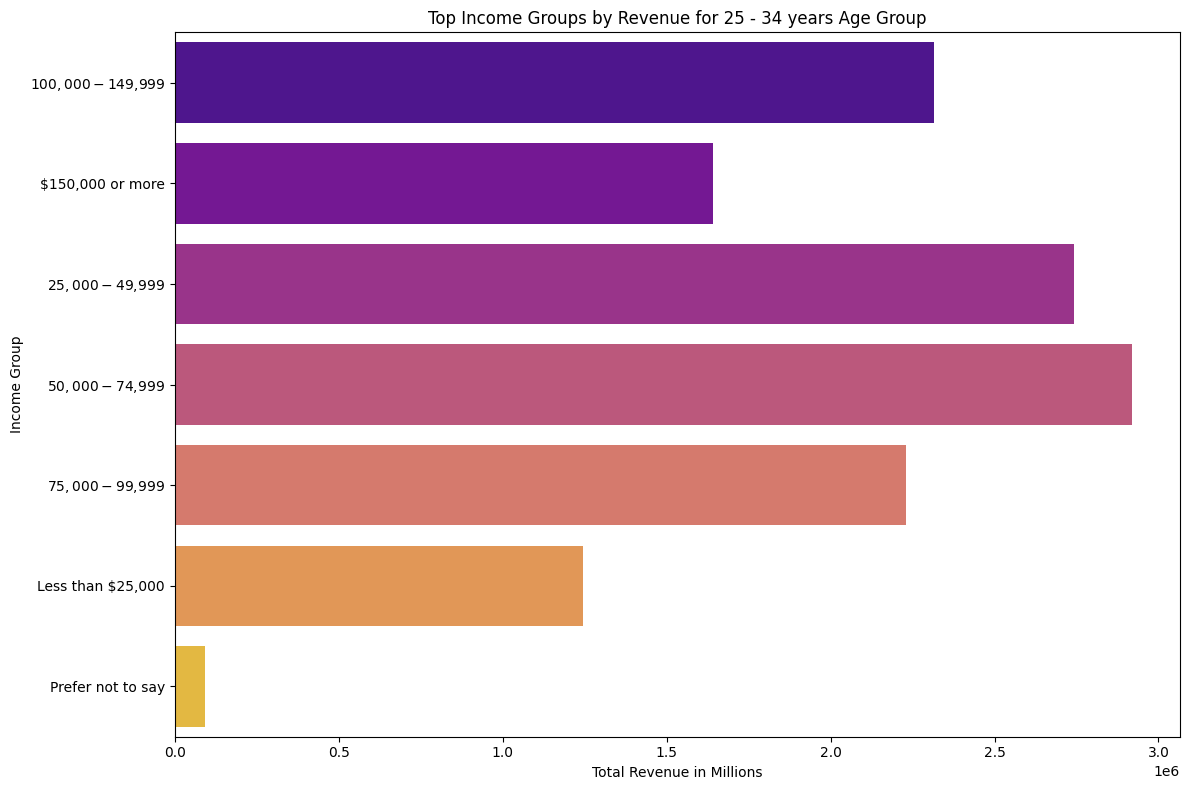

/tmp/ipykernel_2456/1701470441.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_cat_highest_age.values, y=product_cat_highest_age.index, palette='viridis', legend=False)


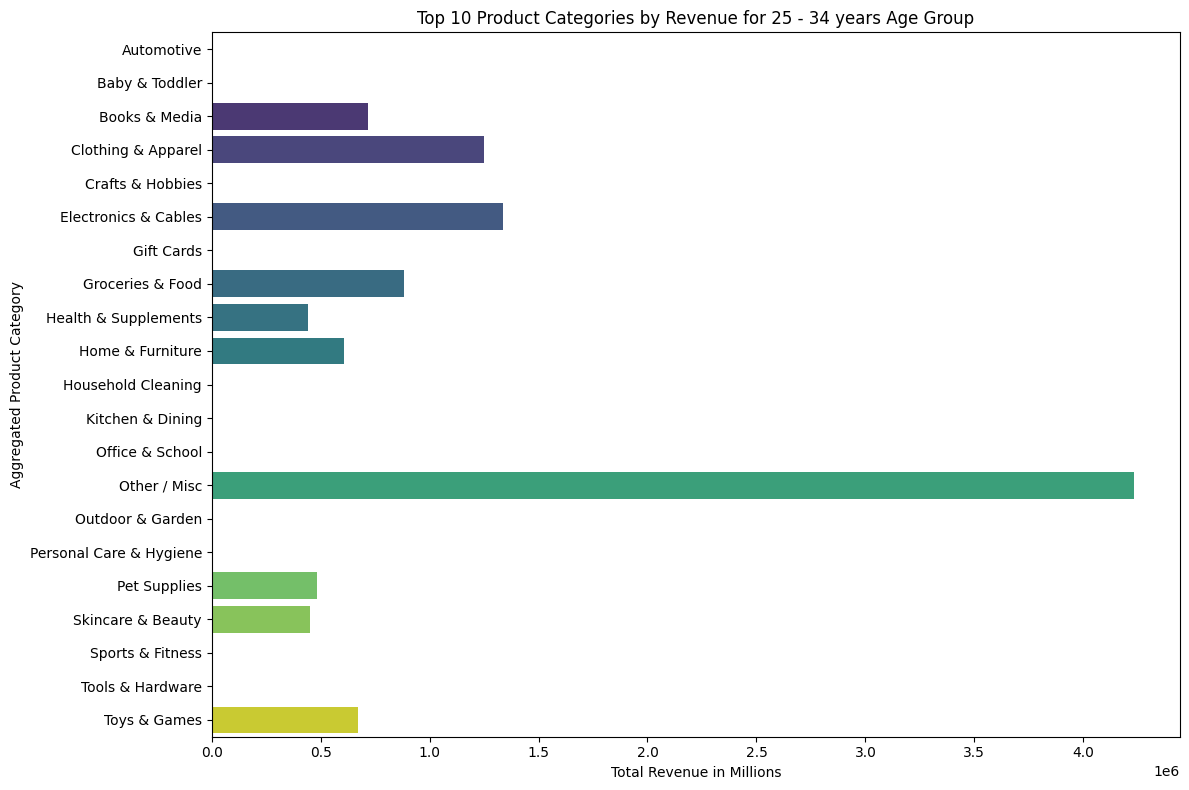


--- Refined View for 25 - 34 years ---


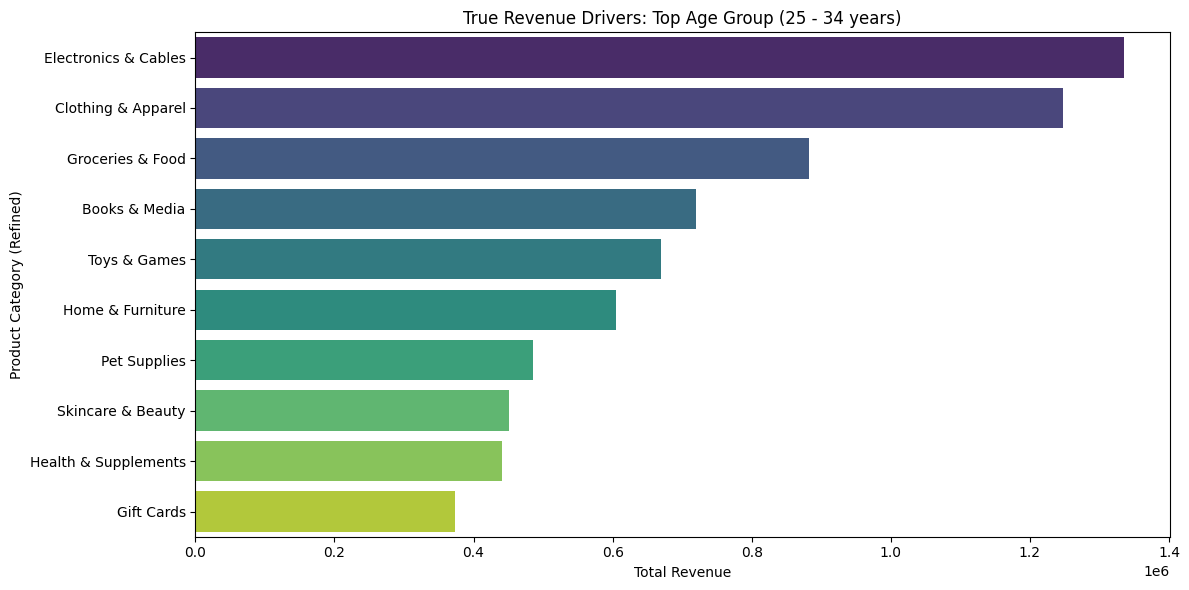

In [ ]:
highest_rev_age_group = age_wise_rev.index[0]

data_highest_age = data[data['Q-demos-age'] == highest_rev_age_group]

income_in_highest_age = data_highest_age.groupby('Q-demos-income', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=income_in_highest_age.values, y=income_in_highest_age.index, palette='plasma', hue=income_in_highest_age.index, legend=False)
plt.title(f'Top Income Groups by Revenue for {highest_rev_age_group} Age Group')
plt.xlabel('Total Revenue in Millions')
plt.ylabel('Income Group')
plt.tight_layout()
plt.show()

product_cat_highest_age = data_highest_age.groupby('Agg_Category', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=product_cat_highest_age.values, y=product_cat_highest_age.index, palette='viridis', legend=False)
plt.title(f'Top 10 Product Categories by Revenue for {highest_rev_age_group} Age Group')
plt.xlabel('Total Revenue in Millions')
plt.ylabel('Aggregated Product Category')
plt.tight_layout()
plt.show()

print(f"\n--- Refined View for {highest_rev_age_group} ---")
plot_refined_analysis(data_highest_age, f'Top Age Group ({highest_rev_age_group})')

**In the 25 - 34 years age group:-**

> - [x] 50,000 to 74,999 is the highest revenue generating income group
> - [x] Electronics and cable is the highest revenue generating category

###Revenue by State

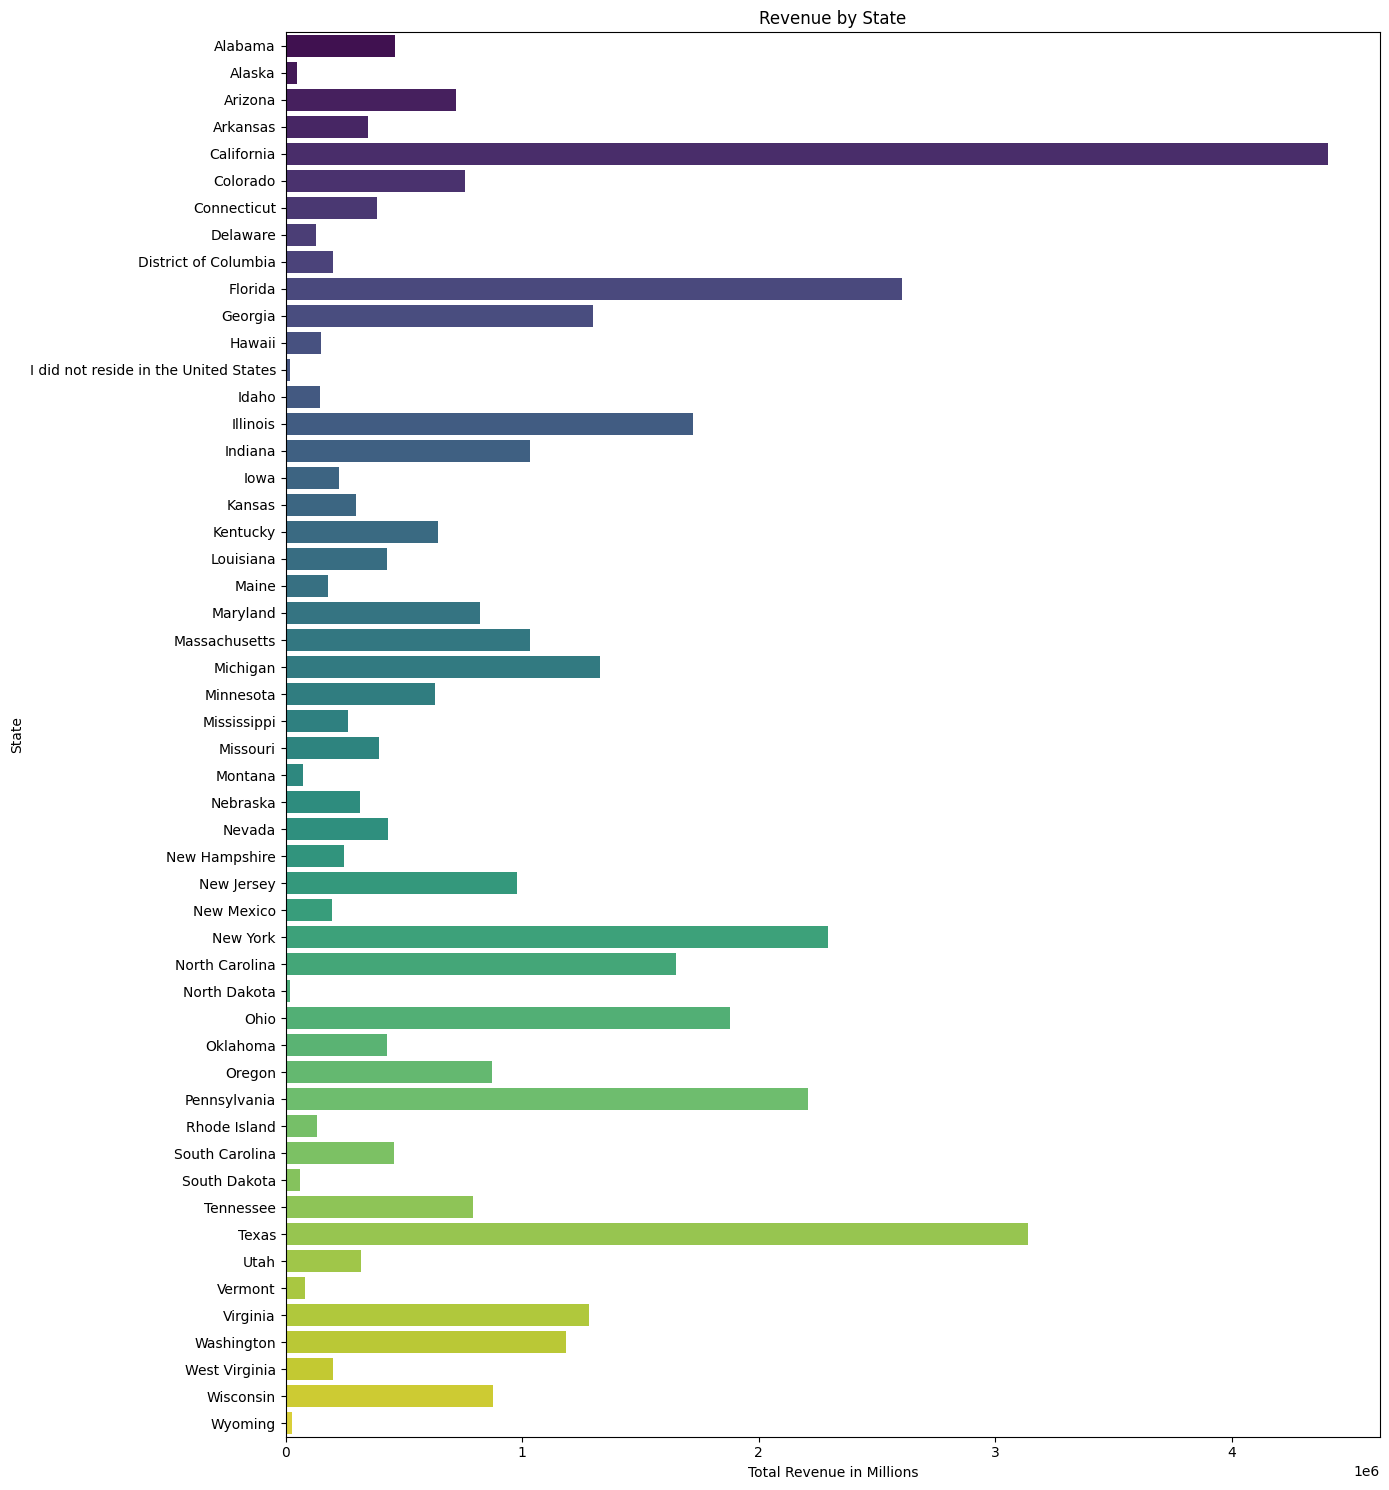

In [ ]:
# 'Q-demos-state'
revenue_state = data.groupby("Q-demos-state", observed=True)["Total Price"].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 15))
sns.barplot(x=revenue_state.values, y=revenue_state.index, palette="viridis", hue=revenue_state.index, legend=False)
plt.title("Revenue by State")
plt.xlabel("Total Revenue in Millions")
plt.ylabel("State")
plt.tight_layout()
plt.show()


> ### State doesn't reflects the shipping address attached to a purchase but it is the survey response 'signifying' *where they are from in the U.S.* ; missing values may occur for digital goods, gift cards, or Amazon-locker deliveries.



This **chart shows which states generate the highest sales**. Demand is different geographically , hence for **logisitcs purposes and marketing**, there must be *different planning for each state*- prioritizing *strongest ones first*!


*   The **highest** or strongest **revenue** is from the state of **California** around more than **4 million** dollars.




#### **Demographic and Product Category Breakdown for Highest Revenue State**

Let's analyze the highest revenue-generating state to understand its dominant product categories, and the contributing age and income groups. This is vital for localized strategies.

/tmp/ipykernel_2456/1459494962.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_cat_highest_state.values, y=product_cat_highest_state.index, palette='viridis', legend=False)


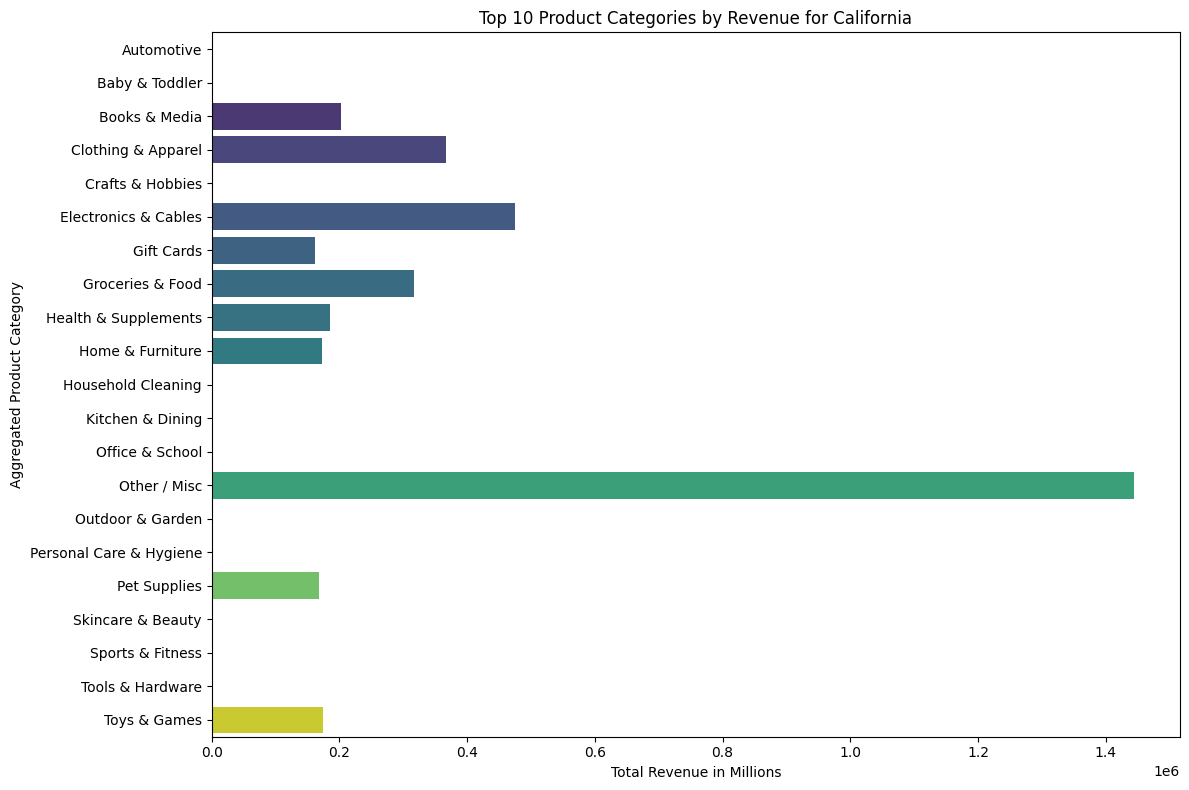


--- Refined View for California ---


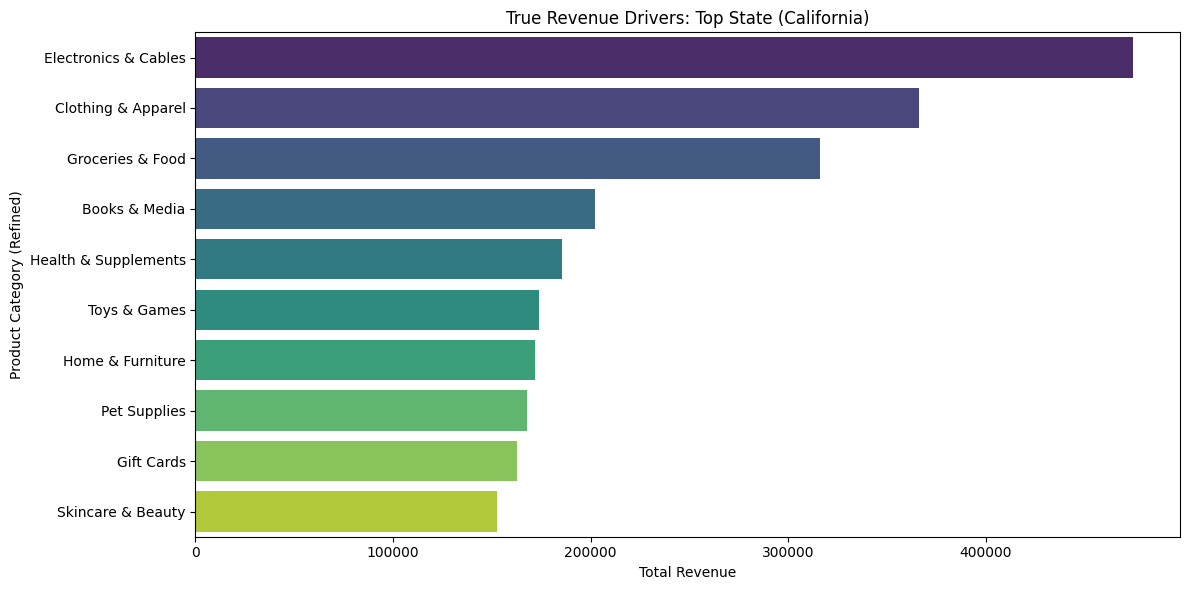

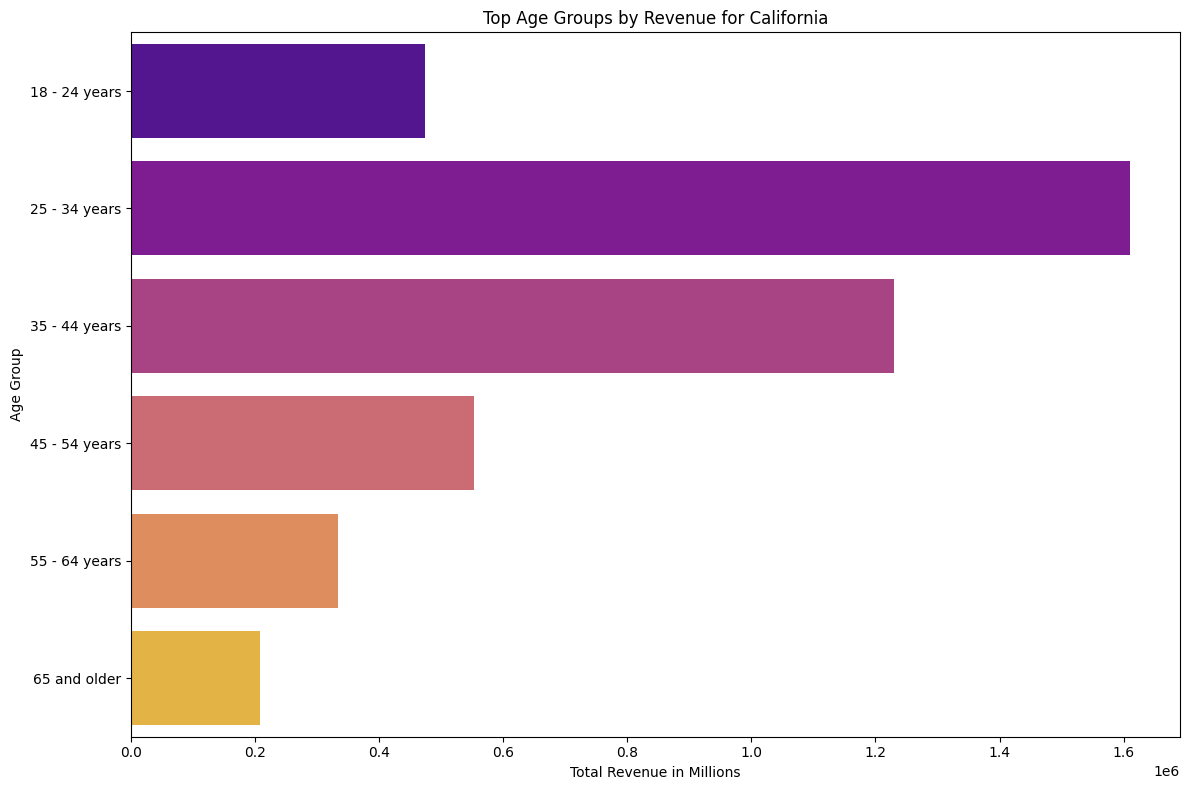

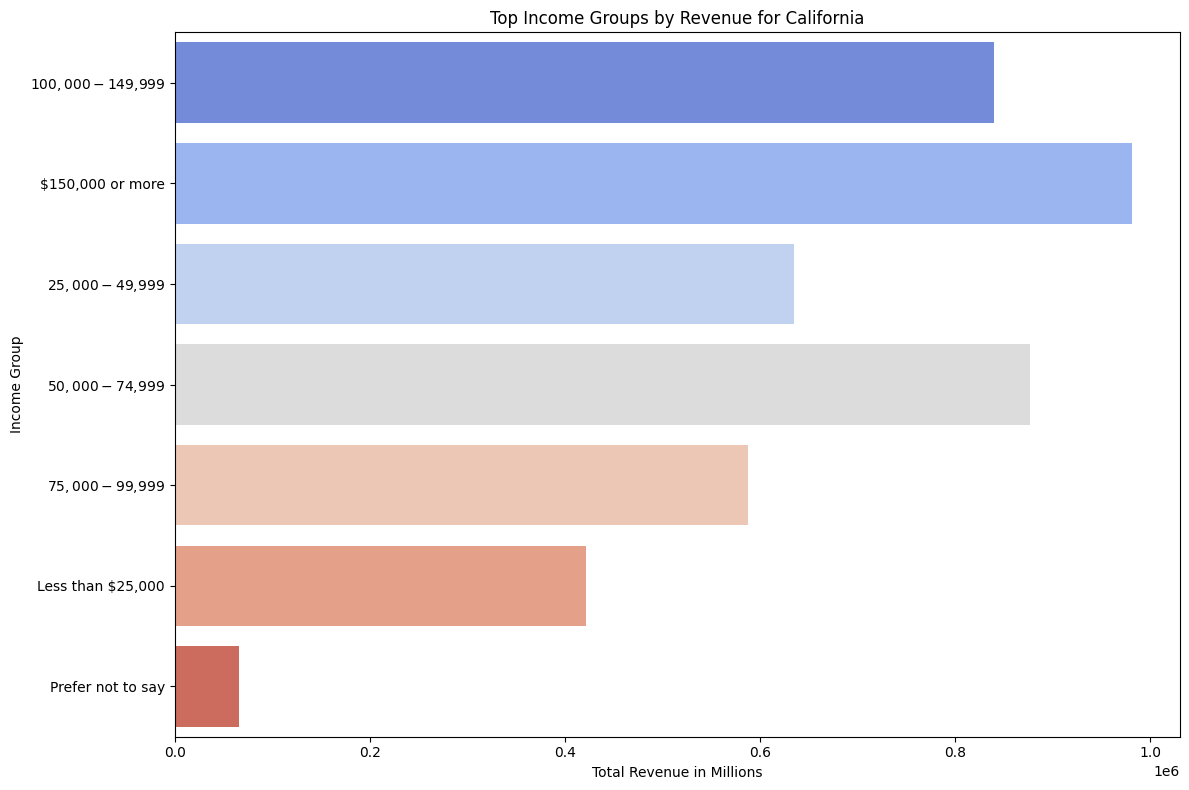

In [ ]:
highest_rev_state = revenue_state.index[0]

data_highest_state = data[data['Q-demos-state'] == highest_rev_state]

product_cat_highest_state = data_highest_state.groupby('Agg_Category', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=product_cat_highest_state.values, y=product_cat_highest_state.index, palette='viridis', legend=False)
plt.title(f'Top 10 Product Categories by Revenue for {highest_rev_state}')
plt.xlabel('Total Revenue in Millions')
plt.ylabel('Aggregated Product Category')
plt.tight_layout()
plt.show()

print(f"\n--- Refined View for {highest_rev_state} ---")
plot_refined_analysis(data_highest_state, f'Top State ({highest_rev_state})')

age_in_highest_state = data_highest_state.groupby('Q-demos-age', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=age_in_highest_state.values, y=age_in_highest_state.index, palette='plasma', hue=age_in_highest_state.index, legend=False)
plt.title(f'Top Age Groups by Revenue for {highest_rev_state}')
plt.xlabel('Total Revenue in Millions')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

income_in_highest_state = data_highest_state.groupby('Q-demos-income', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=income_in_highest_state.values, y=income_in_highest_state.index, palette='coolwarm', hue=income_in_highest_state.index, legend=False)
plt.title(f'Top Income Groups by Revenue for {highest_rev_state}')
plt.xlabel('Total Revenue in Millions')
plt.ylabel('Income Group')
plt.tight_layout()
plt.show()

**For state california:-**
> - [x] 150,000 or more is the highest revenue generating income group
> - [x] 25-34 is the highest revenue generating age group
> - [x] Electronics and cables is the highest revenue generating product category

### Product Categories by State

In [ ]:
# Group by state and aggregated category, then sum Total Price
state_category_revenue = data.groupby(['Q-demos-state', 'Agg_Category'], observed=True)['Total Price'].sum().reset_index()

# Find the highest revenue-generating category for each state
top_category_per_state = state_category_revenue.loc[
    state_category_revenue.groupby('Q-demos-state')['Total Price'].idxmax()
]

print("\nTop 10 States with their highest revenue-generating Aggregated Category:")
display(top_category_per_state.sort_values(by='Total Price', ascending=False).head(10))

# Get the top 3 states by overall revenue (from previous analysis)
top_3_states = data.groupby('Q-demos-state')['Total Price'].sum().nlargest(3).index.tolist()

print("\nTop 5 Aggregated Categories by Revenue for the Top 3 Overall Revenue States:")
for state in top_3_states:
    print(f"\n--- State: {state} ---")
    state_data = state_category_revenue[state_category_revenue['Q-demos-state'] == state]
    display(state_data.sort_values(by='Total Price', ascending=False).head(5))


Top 10 States with their highest revenue-generating Aggregated Category:


/tmp/ipykernel_2456/3993697330.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_category_revenue.groupby('Q-demos-state')['Total Price'].idxmax()


,Q-demos-state,Agg_Category,Total Price
97,California,Other / Misc,1443968.44
933,Texas,Other / Misc,985964.96
202,Florida,Other / Misc,812616.84
703,New York,Other / Misc,709117.04
828,Pennsylvania,Other / Misc,676491.53
765,Ohio,Other / Misc,592471.96
306,Illinois,Other / Misc,542516.67
724,North Carolina,Other / Misc,532056.78
494,Michigan,Other / Misc,428446.71
223,Georgia,Other / Misc,420552.79



Top 5 Aggregated Categories by Revenue for the Top 3 Overall Revenue States:

--- State: California ---


/tmp/ipykernel_2456/3993697330.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_3_states = data.groupby('Q-demos-state')['Total Price'].sum().nlargest(3).index.tolist()


,Q-demos-state,Agg_Category,Total Price
97,California,Other / Misc,1443968.44
89,California,Electronics & Cables,474655.24
87,California,Clothing & Apparel,366438.23
91,California,Groceries & Food,316118.05
86,California,Books & Media,202019.86



--- State: Texas ---


,Q-demos-state,Agg_Category,Total Price
933,Texas,Other / Misc,985964.96
925,Texas,Electronics & Cables,324800.28
923,Texas,Clothing & Apparel,277085.83
927,Texas,Groceries & Food,220163.43
940,Texas,Toys & Games,172796.34



--- State: Florida ---


,Q-demos-state,Agg_Category,Total Price
202,Florida,Other / Misc,812616.84
194,Florida,Electronics & Cables,271763.66
192,Florida,Clothing & Apparel,244936.84
196,Florida,Groceries & Food,170327.53
191,Florida,Books & Media,121226.01


The above analysis identifies *which product categories generate the most revenue within specific states*, allowing for tailored recommendations and strategic planning for specific regions which is crucial for localized marketing and inventory strategies.

> **Providing insights into product performance across different states**.

For example, *in California, **`Other / Misc`** is the highest revenue category*, followed by `Groceries & Food`, `Clothing & Apparel`, `Electronics & Cables`, etc., showing a diverse demand in high-revenue states.

````

#Time patterns


1.   **Monthly trend**

2.   **Days in week pattern**



###Monthly trend

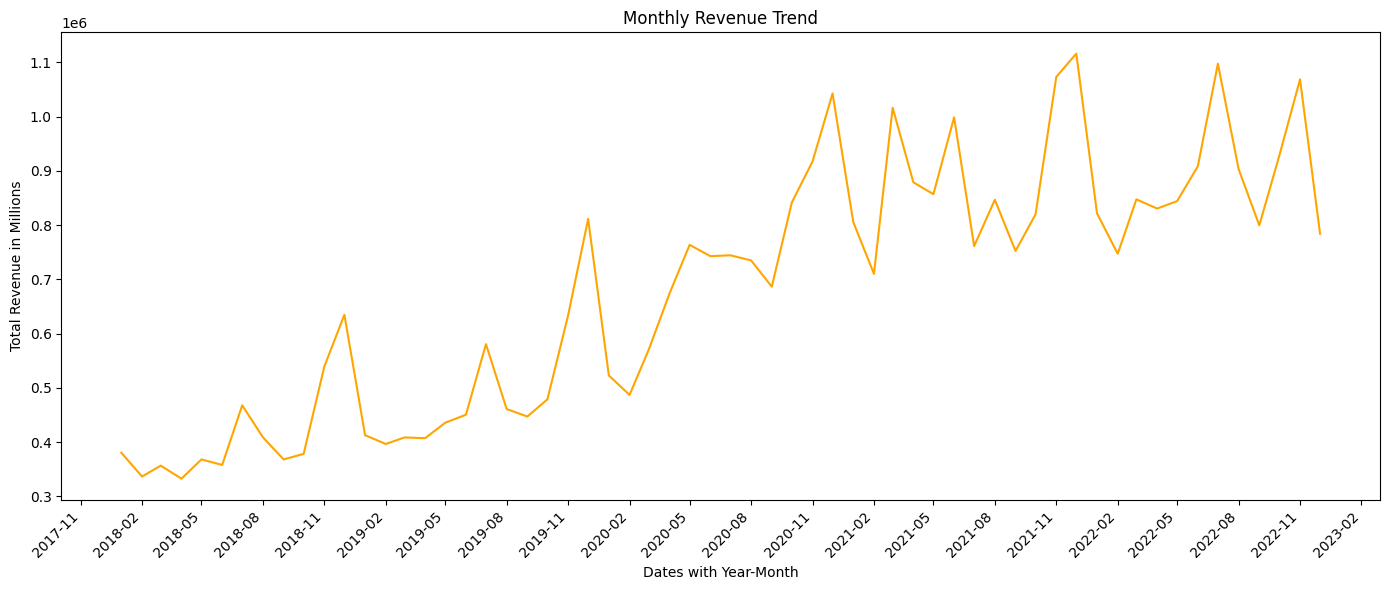

Last recorded month in the data : 2022-12


In [ ]:
import matplotlib.dates as mdates

revenue_monthwise = data.groupby(["Order Year", "Order Month"])["Total Price"].sum().reset_index()
revenue_monthwise["YearandMonth"] = pd.to_datetime(revenue_monthwise["Order Year"].astype(str) + "-" + revenue_monthwise["Order Month"].astype(str) + "-01")

revenue_monthwise_recorded = revenue_monthwise[revenue_monthwise['Total Price'] > 0] # zero revenue is removed at the end

plt.figure(figsize=(14, 6))
sns.lineplot(data=revenue_monthwise_recorded, x="YearandMonth", y="Total Price", color="orange")
plt.title("Monthly Revenue Trend")
plt.xlabel("Dates with Year-Month")
plt.ylabel("Total Revenue in Millions")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3)) # inteveral of 3 months shown in graph
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

month_last_recorded = revenue_monthwise_recorded['YearandMonth'].max()
print(f"Last recorded month in the data : {month_last_recorded.strftime('%Y-%m')}")


**Key Insight and Observation**: The monthly trend is based only on complete years from 2018 through 2022. It shows observed seasonality and changes in aggregate purchase-record value over time.


*   This chart shows how the revenue rises and falls over time and when are the peaks. **Amazon** can **manage inventory and marketing ads** accordingly and consider *steps to take during  high demand periods*.



###Days in week pattern

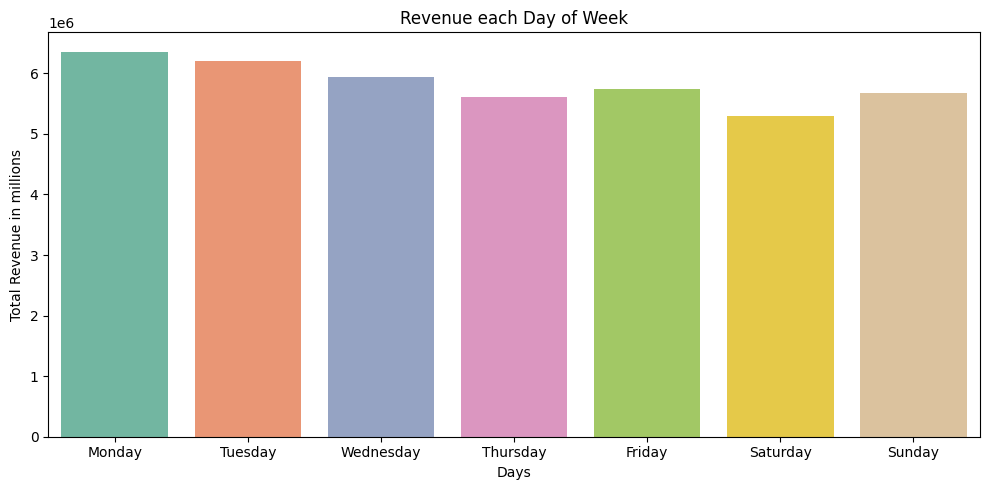

In [ ]:
daysorder = [0, 1, 2, 3, 4, 5, 6] # represents days of week respectively
weekrevenue = data.groupby("Order DayOfWeek", observed=True)["Total Price"].sum().reindex(daysorder) # day of the week when an order was placed

days_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] # actual day names
weekrevenue_day = weekrevenue.rename(index=lambda x: days_week[x])

plt.figure(figsize=(10, 5))
sns.barplot(x=weekrevenue_day.index, y=weekrevenue_day.values, palette="Set2", hue=weekrevenue_day.index, legend=False) # show the names of the days on the x-axis
plt.title("Revenue each Day of Week")
plt.xlabel("Days")
plt.ylabel("Total Revenue in millions")
plt.tight_layout()
plt.show()

The plot shows the total revenue for **each day of the week**, summed **across all the years** in our data.


*   This *chart shows how buying behavior changes across the week*. Amazon can time their campaigns and promotions for those *days of the week when customers are most active*.
*  The *highest sales/revenue is on **mondays*** which is more than around *6 million*.



#### **Detailed Analysis for Highest Revenue Day of the Week**

Let's investigate the day of the week with the highest revenue to identify the key demographics and product categories driving sales on that specific day. This can inform optimal timing for promotions and resource allocation.

/tmp/ipykernel_2456/3870214415.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_cat_highest_day.values, y=product_cat_highest_day.index, palette='magma', legend=False)


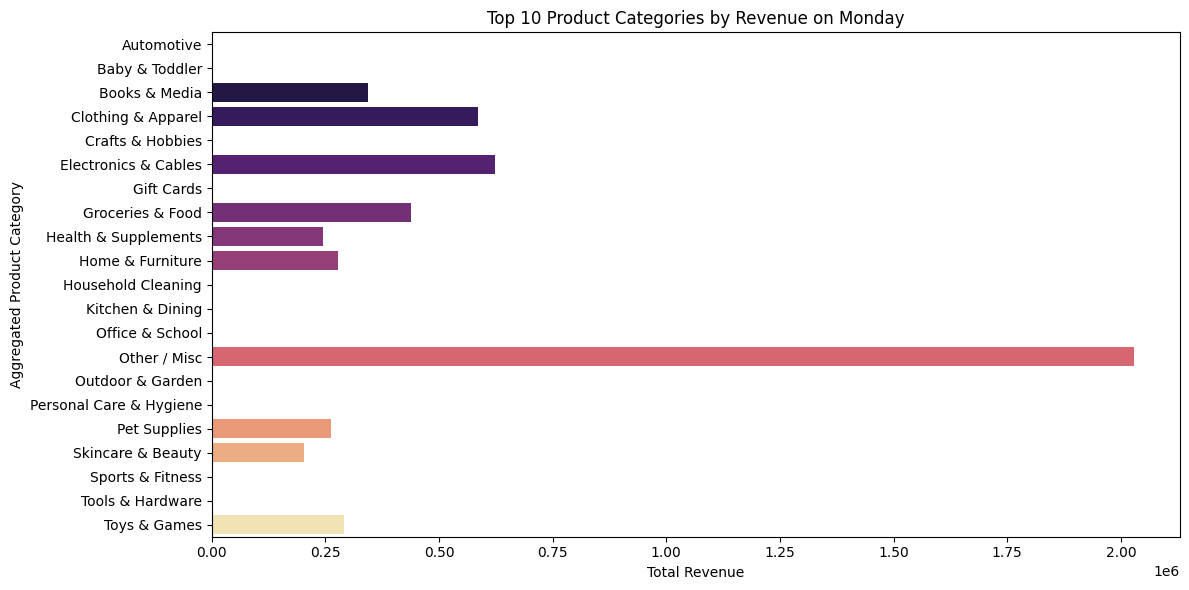


--- Refined View for Monday ---


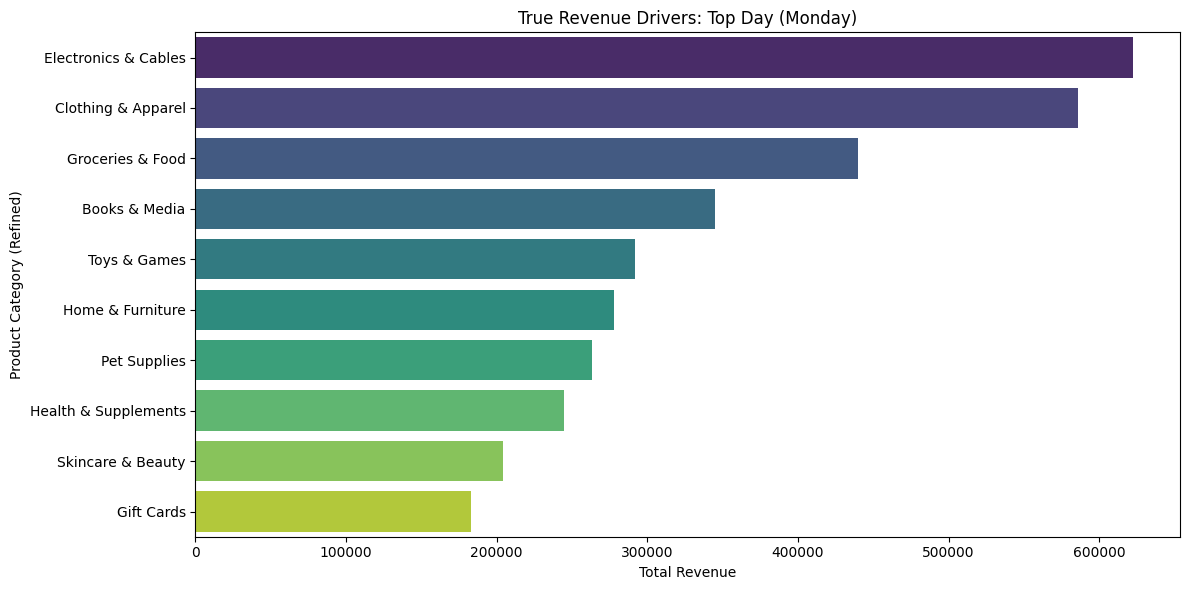

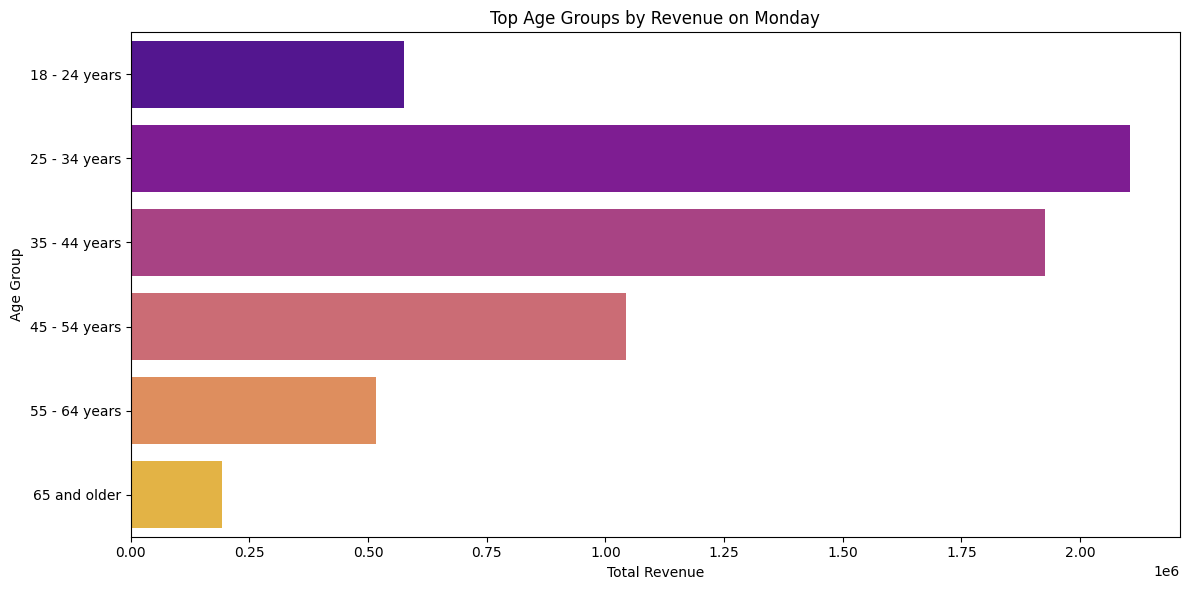

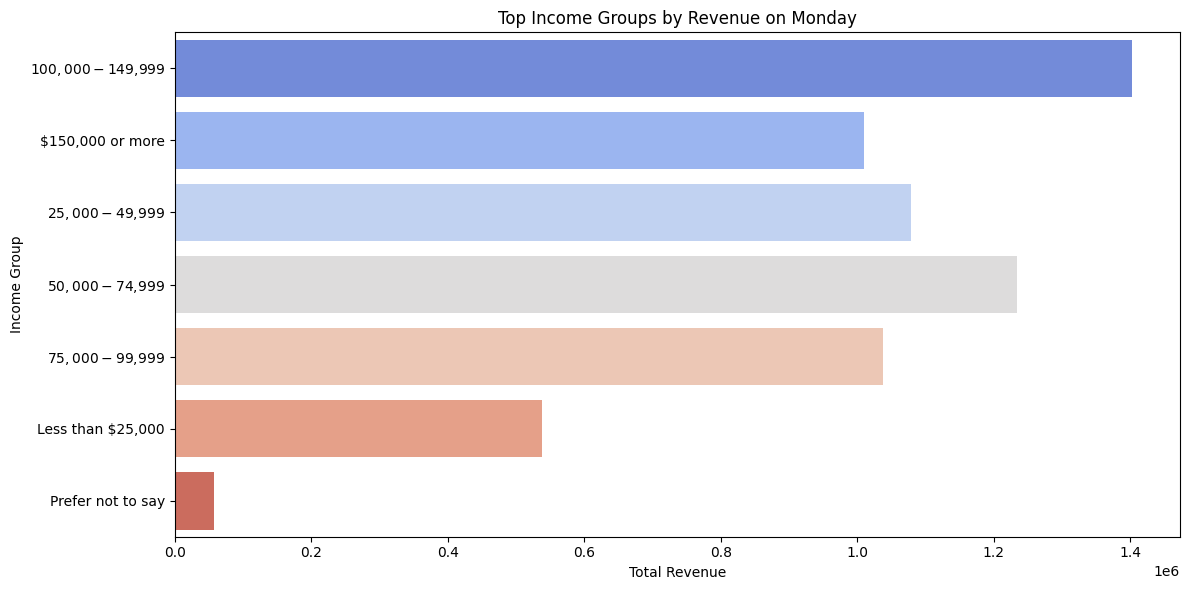

/tmp/ipykernel_2456/3870214415.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_in_highest_day.values, y=state_in_highest_day.index, palette='viridis', legend=False)


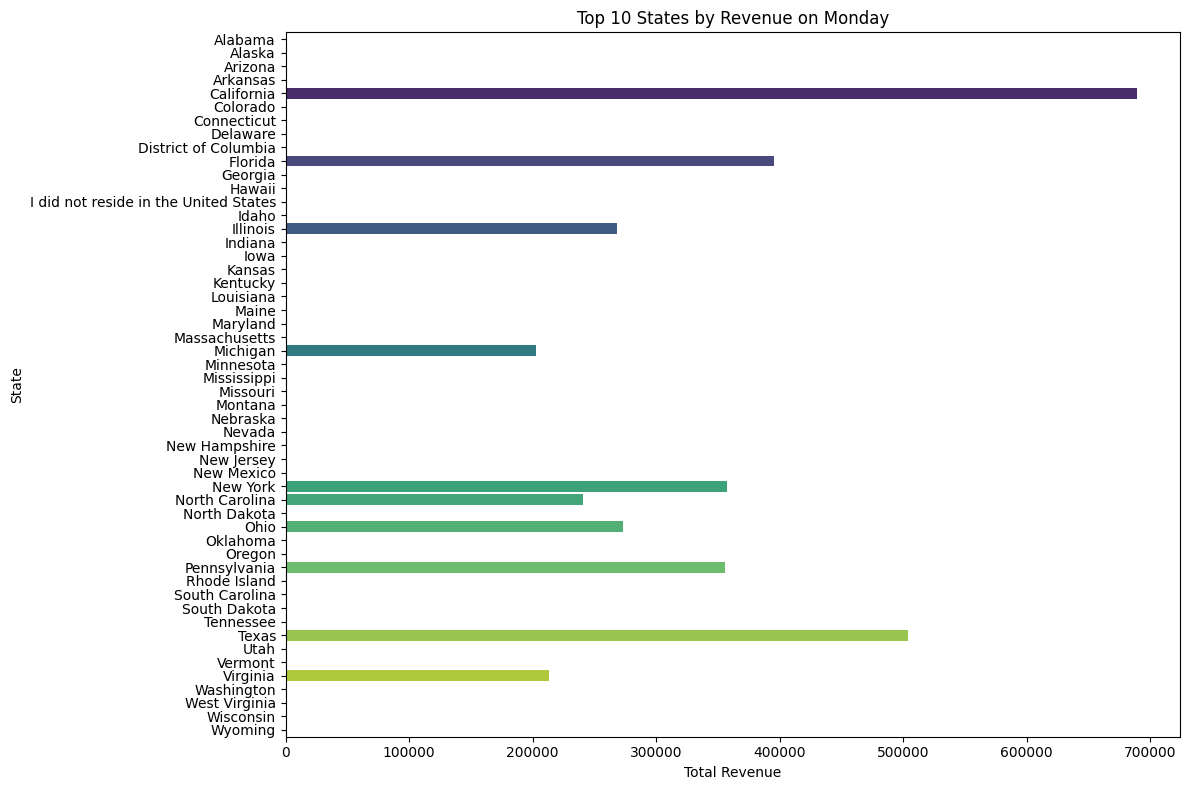

In [ ]:
highest_rev_day_index = weekrevenue.idxmax()
highest_rev_day_name = days_week[highest_rev_day_index]

data_highest_day = data[data['Order DayOfWeek'] == highest_rev_day_index]

product_cat_highest_day = data_highest_day.groupby('Agg_Category', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=product_cat_highest_day.values, y=product_cat_highest_day.index, palette='magma', legend=False)
plt.title(f'Top 10 Product Categories by Revenue on {highest_rev_day_name}')
plt.xlabel('Total Revenue')
plt.ylabel('Aggregated Product Category')
plt.tight_layout()
plt.show()

print(f"\n--- Refined View for {highest_rev_day_name} ---")
plot_refined_analysis(data_highest_day, f'Top Day ({highest_rev_day_name})')

age_in_highest_day = data_highest_day.groupby('Q-demos-age', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=age_in_highest_day.values, y=age_in_highest_day.index, palette='plasma', hue=age_in_highest_day.index, legend=False)
plt.title(f'Top Age Groups by Revenue on {highest_rev_day_name}')
plt.xlabel('Total Revenue')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

income_in_highest_day = data_highest_day.groupby('Q-demos-income', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=income_in_highest_day.values, y=income_in_highest_day.index, palette='coolwarm', hue=income_in_highest_day.index, legend=False)
plt.title(f'Top Income Groups by Revenue on {highest_rev_day_name}')
plt.xlabel('Total Revenue')
plt.ylabel('Income Group')
plt.tight_layout()
plt.show()

state_in_highest_day = data_highest_day.groupby('Q-demos-state', observed=True)['Total Price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8)) # Increased figure height for better label visibility
sns.barplot(x=state_in_highest_day.values, y=state_in_highest_day.index, palette='viridis', legend=False)
plt.title(f'Top 10 States by Revenue on {highest_rev_day_name}')
plt.xlabel('Total Revenue')
plt.ylabel('State')
plt.yticks(rotation=0) # Ensure labels are horizontal
plt.tight_layout()
plt.show()

**On Monday, the highest revenue generation is from:-**
> - [x] electronics and cables  
> - [x] 25-34 age
> - [x] california  
> - [x] 100,000-149,999 income group

In [ ]:
def get_refined_top_categories(df, top_n=10):
    """Helper to reveal true drivers by breaking down Misc categories."""
    agg_rev = df.groupby('Agg_Category', observed=True)['Total Price'].sum().sort_values(ascending=False)
    misc_breakdown = df[df['Agg_Category'] == 'Other / Misc'].groupby('Category', observed=True)['Total Price'].sum()
    refined_list = pd.concat([agg_rev.drop(labels=['Other / Misc'], errors='ignore'), misc_breakdown])
    return refined_list.sort_values(ascending=False).head(top_n)

def plot_refined_analysis(df, title):
    """Generates a bar plot for the refined revenue drivers."""
    refined_data = get_refined_top_categories(df)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=refined_data.values, y=refined_data.index.astype(str), palette='viridis', hue=refined_data.index.astype(str), legend=False)
    plt.title(f'True Revenue Drivers: {title}')
    plt.xlabel('Total Revenue')
    plt.ylabel('Product Category (Refined)')
    plt.tight_layout()
    plt.show()



---



#Outliers
###Boxplot

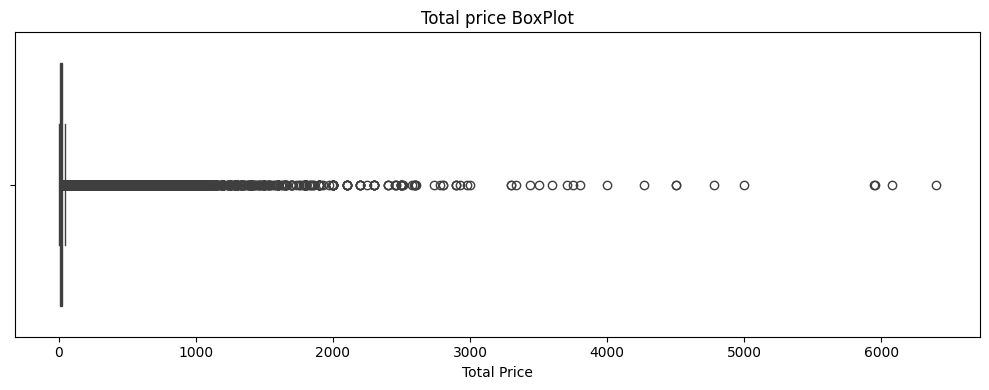

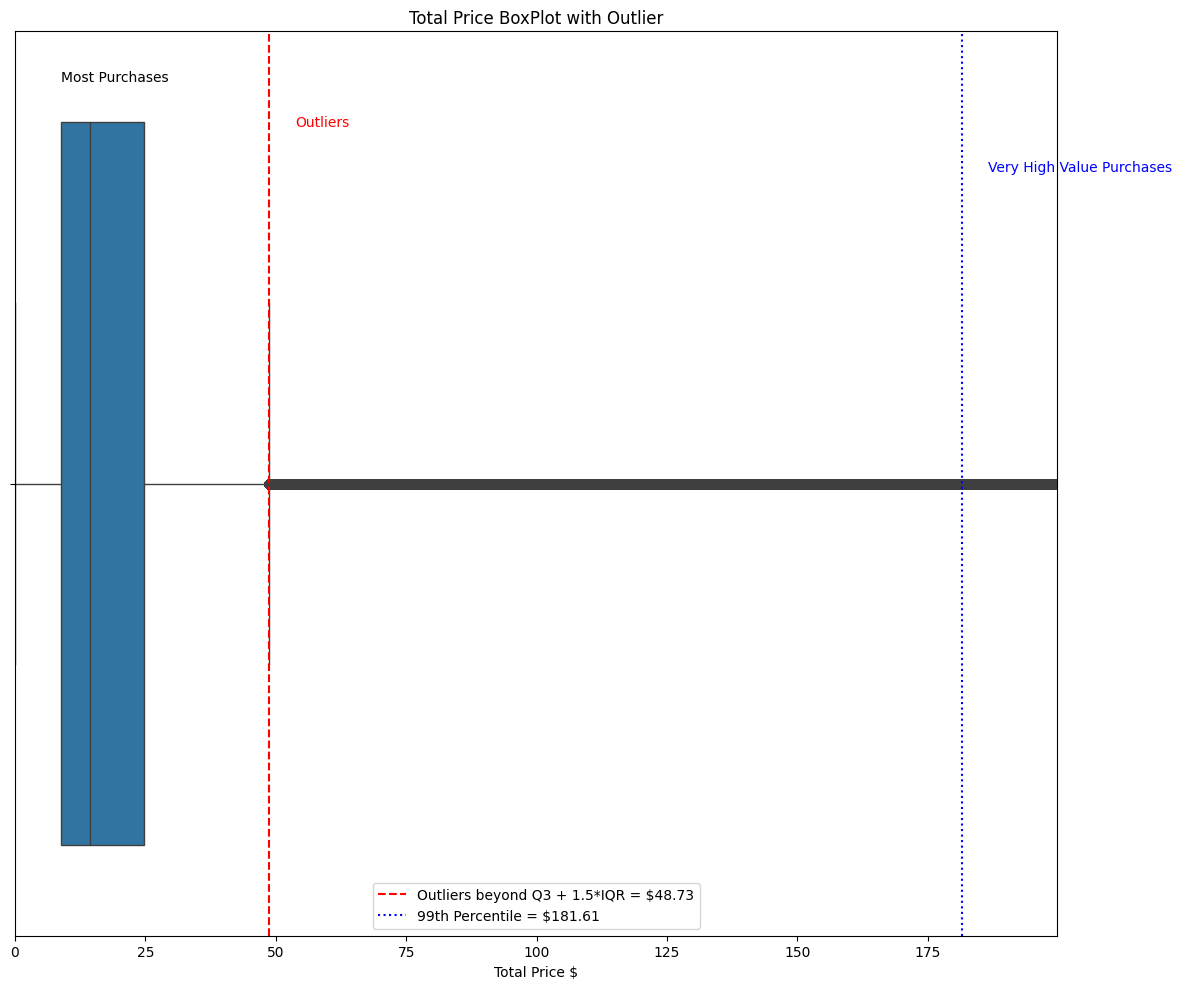

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=data["Total Price"])
plt.title("Total price BoxPlot")
plt.xlabel("Total Price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.boxplot(x=data["Total Price"])
plt.title("Total Price BoxPlot with Outlier")
plt.xlabel("Total Price $")

# Quartiles Q1, Q3, and Inter Quartile Range IQR
Q1 = data["Total Price"].quantile(0.25)
Q3 = data["Total Price"].quantile(0.75)
IQR = Q3 - Q1

# Upper bound for outliers 1.5 * IQR
upperbound = Q3 + 1.5 * IQR

# 99th percentile
percentile99th = data["Total Price"].quantile(0.99)

plt.xlim(0, percentile99th * 1.1) # Show up to 110% of the 99th percentile

# Indicate the upper bound of purchases using IQR
plt.axvline(x=upperbound, color='red', linestyle='--', label=f'Outliers beyond Q3 + 1.5*IQR = ${upperbound:.2f}')

# Indicate 99th percentile
plt.axvline(x=percentile99th, color='blue', linestyle=':', label=f'99th Percentile = ${percentile99th:.2f}')

# Add text annotations for interpretation
plt.text(upperbound + 5, plt.ylim()[1] * 0.8, 'Outliers', color='red', ha='left', va='center', fontsize=10)
plt.text(percentile99th + 5, plt.ylim()[1] * 0.7, 'Very High Value Purchases', color='blue', ha='left', va='center', fontsize=10)
plt.text(Q1, plt.ylim()[1] * 0.9, 'Most Purchases', color='black', ha='left', va='center', fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

### Boxplot: Total Price Distribution

The  visualization depicts the highly skewed nature of 'Total Price' distribution:

*   **Right-Skewed Distribution**: The median is closer to the left side of the box. Majority of purchases are for smaller amounts. A few large ones pull the mean to the right. Thus there are many small values and few large ones.
*   **Outliers**: Purchases more than **`$48.73`** (`Q3 + 1.5 * IQR`) are outliers, significantly different from the majority.
*   **Very High-Value Purchase**: The **99th percentile at `$181.61`** highlights high-value transactions. About 1% of purchases exceed this making rare ones!

**Key Observation**: *Amazon should not ignore high-value customers because they can contribute a disproportionate share of revenue.*


---



## Business Insights

From the EDA - exploratory data analysis done above, we can infer/derive very valuable **business insights**:

*   **Revenue Distribution**: The **`Total Price`** distribution is *highly skewed*, having *many low value transactions* and a very few high-value ones which make disproportionate contribution to overall revenue. *Inexpensive items give the most volume*. Still *focusing on high-value customers and transactions* is in a way important for *maximizing total revenue*.

*   **Product Categories Sold**:
    *   In original `Category` column, **'ABIS_BOOK'** is the most purchased category item.
    *   In the aggregated **`Agg_Category`** column, **'Groceries & Food'** is most purchased category.
    *   From this we *inform* ourselves of **inventory planning, specific promotions, advertisements and product development/management strategies**.

*   **Income Group Contribution**: The income group **$100,000 - $149,999** generates the highest total revenue. Specific income groups are most valuable and can be focused upon and sending them specific marketing campaigns with product offerings and advertisements.

*   **Age Group Contribution**: Customers in the **25 - 34 years** age group contribute the most revenue, very ahead of others. Age-based market categorisation, product recommendations, and advertisements can be very useful.

*   **Geographic Revenue Contribution**: **California** state generates the highest total revenue. We have therefore regional differences in demand, thus giving us knowledge of logistics, and localized marketing.

*   **Monthly and Daily Revenue Trends**:
    * There is a *sharp increase* at round **end of 2021**. Amazon can identify monthly periods of very high or demand and manage inventory, plan marketing campaigns.
    * Similarly in **daily pattern**, **Mondays** generate *the highest revenue* from any other day of the week. This tells, customers are *mostly active at the beginning of the week* for purchase on Amazon. This then is very useful to correctly time promotions and allocate resources.
* **Mean line-item value**: $23.70
  
* **Median line-item value**: $14.49



---



### **Interpretation and Limitation**:
    1. This is a volunteer, crowdsourced sample of 5,027 U.S. Amazon users; it is not fully representative of all U.S. Amazon customers in this study sample.
    
    2. Purchase records are linked to survey demographics through Survey ResponseID.

    3. Shipping state can be missing for digital products, gift cards, and Amazon-locker deliveries.

    4. Keyword-based aggregation improves readability but leaves a large `Other / Misc` residual group.

    5. The results / conclusions / insights are supported by our sample analysis, not as generalisations or facts about Amazon’s entire U.S. customer base.






---



**Dashboard**

In [ ]:
# @title Amazon Purchase Strategic Dashboard {display-mode: "form"}

import pandas as pd
import json
from IPython.display import HTML, display

try:
    from google.colab import output
except Exception:
    output = None

def get_dashboard_data():
    global data
    month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
    day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    available_years = sorted(data["Order Year"].dropna().astype(int).unique().tolist())
    available_states = sorted(data["Q-demos-state"].dropna().astype(str).unique().tolist())

    year_month_map = {}
    for yr in available_years:
        months = sorted(data.loc[data["Order Year"].astype(int) == yr, "Order Month"].dropna().astype(int).unique().tolist())
        year_month_map[int(yr)] = [{"val": int(m), "name": month_names.get(int(m), str(m))} for m in months]

    filter_cols = ["Order Year", "Order Month", "Q-demos-state"]

    # KPIs
    kpi_data = data.groupby(filter_cols, observed=True).agg({"Total Price": ["sum", "mean"], "Survey ResponseID": "nunique"}).reset_index()
    kpi_data.columns = ["year", "month", "state", "rev", "aov", "users"]
    kpi_data["orders"] = data.groupby(filter_cols, observed=True).size().values

    # Trend
    trend_data = data.groupby(["Order Year", "Order Month", "Q-demos-state"], observed=True)["Total Price"].sum().reset_index()
    trend_data.columns = ["year", "month", "state", "rev"]

    # Day of Week
    dow_data = data.groupby(filter_cols + ["Order DayOfWeek"], observed=True)["Total Price"].sum().reset_index()
    dow_data.columns = ["year", "month", "state", "dow", "rev"]

    # Categories
    temp_df = data.copy()
    temp_df["Display_Category"] = temp_df["Agg_Category"].astype(str)
    mask = temp_df["Display_Category"] == "Other / Misc"
    temp_df.loc[mask, "Display_Category"] = temp_df.loc[mask, "Category"].astype(str)
    cat_data = temp_df.groupby(filter_cols + ["Display_Category"], observed=True).size().reset_index(name="count")
    cat_data.columns = ["year", "month", "state", "Display_Category", "count"]

    # Age
    age_data = data.groupby(filter_cols + ["Q-demos-age"], observed=True)["Total Price"].sum().reset_index()
    age_data.columns = ["year", "month", "state", "Q-demos-age", "Total Price"]

    return {
        "years": available_years,
        "states": available_states,
        "month_labels": [month_names[i] for i in range(1, 13)],
        "day_labels": day_names,
        "year_month_map": year_month_map,
        "overall_kpis": {
            "total_revenue": float(data["Total Price"].sum()),
            "total_orders": int(len(data)),
            "avg_order_value": float(data["Total Price"].mean()),
            "unique_customers": int(data["Survey ResponseID"].nunique())
        },
        "kpi_map": kpi_data.to_dict("records"),
        "trend_map": trend_data.to_dict("records"),
        "dow_map": dow_data.to_dict("records"),
        "categories": cat_data.to_dict("records"),
        "age": age_data.to_dict("records")
    }

try:
    dashboard_json = json.dumps(get_dashboard_data())
except Exception as e:
    dashboard_json = json.dumps({"error": f"Data error: {str(e)}"})

html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;800&display=swap" rel="stylesheet">
<style>
    :root { --bg: #f7fafc; --card: #ffffff; --border: #e2e8f0; --text: #1a202c; --muted: #718096; --primary: #4c51bf; --bar-bg: #edf2f7; }
    * { box-sizing: border-box; }
    body { margin: 0; background: var(--bg); color: var(--text); font-family: 'Inter', sans-serif; overflow-x: hidden; }
    .dashboard { width: 100%; max-width: 100%; margin: 0 auto; padding: 20px; }
    .topbar { display: flex; align-items: center; justify-content: space-between; margin-bottom: 24px; background: var(--card); padding: 16px 24px; border-radius: 12px; box-shadow: 0 1px 3px rgba(0,0,0,0.1); flex-wrap: wrap; gap: 16px; }
    .title-row { display: flex; align-items: center; gap: 24px; }
    h1 { margin: 0; font-size: 20px; font-weight: 800; color: #000; }
    .filters { display: flex; gap: 12px; flex-wrap: wrap; }
    .filter { display: flex; flex-direction: column; gap: 4px; }
    .filter label { font-size: 10px; font-weight: 700; color: var(--muted); text-transform: uppercase; }
    .filter select { border: 1px solid var(--border); background: white; padding: 6px 10px; border-radius: 6px; font-size: 12px; font-weight: 600; }
    .kpis { display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 20px; margin-bottom: 24px; }
    .kpi { background: var(--card); border-radius: 12px; padding: 20px; box-shadow: 0 1px 3px rgba(0,0,0,0.1); border-top: 4px solid var(--primary); }
    .kpi-label { font-size: 12px; font-weight: 600; color: var(--muted); margin-bottom: 4px; }
    .kpi-value { font-size: 22px; font-weight: 800; color: var(--text); }
    .card { background: var(--card); border-radius: 12px; padding: 20px; box-shadow: 0 1px 3px rgba(0,0,0,0.1); margin-bottom: 24px; display: flex; flex-direction: column; }
    .card h2 { margin: 0 0 15px 0; font-size: 15px; font-weight: 700; color: var(--text); }
    .grid-3 { display: grid; grid-template-columns: repeat(auto-fit, minmax(350px, 1fr)); gap: 24px; }
    .canvas-wrapper { position: relative; flex-grow: 1; min-height: 250px; min-height: 0; }
    .html-bars { display: flex; flex-direction: column; gap: 10px; }
    .bar-row { width: 100%; }
    .bar-head { display: flex; justify-content: space-between; font-size: 11px; font-weight: 700; margin-bottom: 4px; }
    .bar-bg { height: 8px; background: var(--bar-bg); border-radius: 4px; width: 100%; }
    .bar-fill { height: 100%; background: var(--primary); border-radius: 4px; }
    #catLegend { display: grid; grid-template-columns: 1fr; gap: 5px; margin-top: 15px; max-height: 100px; overflow-y: auto; }
</style>
</head>
<body>
<div class="dashboard">
    <div class="topbar">
        <div class="title-row"><h1>Strategic Market Insights (US$)</h1></div>
        <div class="filters">
            <div class="filter"><label>Year</label><select id="yearSelect"><option value="all">All Years</option></select></div>
            <div class="filter"><label>Month</label><select id="monthSelect"><option value="all">All Months</option></select></div>
            <div class="filter"><label>State Filter</label><select id="stateSelect"><option value="all">All States</option></select></div>
        </div>
    </div>
    <section class="kpis">
        <div class="kpi"><div class="kpi-label">Total Revenue</div><div class="kpi-value" id="kpi-rev">$0</div></div>
        <div class="kpi"><div class="kpi-label">Order Volume</div><div class="kpi-value" id="kpi-orders">0</div></div>
        <div class="kpi"><div class="kpi-label">Mean purchase-record value</div><div class="kpi-value" id="kpi-aov">$0</div></div>
        <div class="kpi"><div class="kpi-label">Active Panelists</div><div class="kpi-value" id="kpi-users">0</div></div>
    </section>
    <section class="card" style="height: 350px;">
        <h2>Monthly Revenue Trend (US$)</h2>
        <div class="canvas-wrapper"><canvas id="trendChart"></canvas></div>
    </section>
    <div class="grid-3">
        <div class="card"><h2>Revenue by State (Top 8)</h2><div class="html-bars" id="stateBars"></div></div>
        <div class="card"><h2>Product Category Share</h2><div class="canvas-wrapper"><canvas id="catChart"></canvas></div><div id="catLegend"></div></div>
        <div class="card"><h2>Revenue by Day</h2><div class="canvas-wrapper"><canvas id="dowChart"></canvas></div></div>
    </div>
    <section class="card" style="margin-top:24px;"><h2>Top Age Segments (Revenue)</h2><div id="ageBars" class="html-bars"></div></section>
</div>
<script>
const rawData = DATA_PLACEHOLDER;
let charts = {};
const COLORS = ['#4c51bf', '#38b2ac', '#f6ad55', '#ed64a6', '#9f7aea', '#667eea', '#ecc94b', '#f56565', '#48bb78', '#a0aec0'];

function formatCurrency(v) { return new Intl.NumberFormat("en-US", { style: "currency", currency: "USD", maximumFractionDigits: 0 }).format(v || 0); }

function init() {
    if (rawData.error) return;
    const ySel = document.getElementById("yearSelect");
    const sSel = document.getElementById("stateSelect");
    rawData.years.forEach(y => { const opt = document.createElement("option"); opt.value = y; opt.textContent = y; ySel.appendChild(opt); });
    rawData.states.forEach(s => { const opt = document.createElement("option"); opt.value = s; opt.textContent = s; sSel.appendChild(opt); });
    ySel.addEventListener("change", () => { updateMonthDropdown(); updateDashboard(); });
    document.getElementById("monthSelect").addEventListener("change", updateDashboard);
    sSel.addEventListener("change", updateDashboard);
    updateDashboard();

    // Force layout recalculation after initial render
    setTimeout(() => { Object.values(charts).forEach(c => c.resize()); }, 200);
}

function updateMonthDropdown() {
    const yr = document.getElementById("yearSelect").value;
    const mSel = document.getElementById("monthSelect");
    mSel.innerHTML = '<option value="all">All Months</option>';
    if (yr !== "all" && rawData.year_month_map[yr]) {
        rawData.year_month_map[yr].forEach(m => { const opt = document.createElement("option"); opt.value = m.val; opt.textContent = m.name; mSel.appendChild(opt); });
    }
}

function updateDashboard() {
    const f = { year: document.getElementById("yearSelect").value, month: document.getElementById("monthSelect").value, state: document.getElementById("stateSelect").value };
    const match = (d) => (f.year==='all'||String(d.year)===f.year) && (f.month==='all'||String(d.month)===f.month) && (f.state==='all'||String(d.state)===f.state);

    const kpiRows = rawData.kpi_map.filter(match);
    const kpis = kpiRows.reduce((a,b) => ({rev: a.rev+b.rev, orders: a.orders+b.orders, users: Math.max(a.users, b.users)}), {rev:0, orders:0, users:0});
    document.getElementById("kpi-rev").innerText = formatCurrency(kpis.rev);
    document.getElementById("kpi-orders").innerText = kpis.orders.toLocaleString();
    document.getElementById("kpi-aov").innerText = formatCurrency(kpis.orders ? kpis.rev/kpis.orders : 0);
    document.getElementById("kpi-users").innerText = kpis.users.toLocaleString();

    updateTrend(f);
    updateStateBars(f);
    updateCategoryChart(f);
    updateDowChart(f);
    updateAgeBars(f);
}

function updateTrend(f) {
    const rows = rawData.trend_map.filter(d => (f.year==='all'||String(d.year)===f.year) && (f.state==='all'||String(d.state)===f.state));
    const agg = {}; rows.forEach(d => agg[d.month] = (agg[d.month] || 0) + d.rev);
    const values = rawData.month_labels.map((_, i) => agg[i+1] || 0);
    if (charts.trend) charts.trend.destroy();
    charts.trend = new Chart(document.getElementById("trendChart"), {
        type: 'line', data: { labels: rawData.month_labels, datasets: [{ data: values, borderColor: '#4c51bf', backgroundColor: 'rgba(76, 81, 191, 0.1)', fill: true, tension: 0.4 }] },
        options: { responsive: true, maintainAspectRatio: false, plugins: { legend: { display: false } } }
    });
}

function updateStateBars(f) {
    const rows = rawData.kpi_map.filter(d => (f.year==='all'||String(d.year)===f.year) && (f.month==='all'||String(d.month)===f.month));
    const agg = {}; rows.forEach(d => agg[d.state] = (agg[d.state] || 0) + d.rev);
    const sorted = Object.entries(agg).sort((a,b) => b[1]-a[1]).slice(0, 8);
    const max = sorted.length ? sorted[0][1] : 1;
    document.getElementById("stateBars").innerHTML = sorted.map(([n, v]) => `
        <div class="bar-row">
            <div class="bar-head"><span>${n}</span><span>${formatCurrency(v)}</span></div>
            <div class="bar-bg"><div class="bar-fill" style="width:${(v/max)*100}%"></div></div>
        </div>`).join('');
}

function updateCategoryChart(f) {
    const rows = rawData.categories.filter(d => (f.year==='all'||String(d.year)===f.year) && (f.month==='all'||String(d.month)===f.month) && (f.state==='all'||String(d.state)===f.state));
    const agg = {}; rows.forEach(d => agg[d.Display_Category] = (agg[d.Display_Category] || 0) + d.count);
    const sorted = Object.entries(agg).sort((a,b) => b[1]-a[1]).slice(0, 10);
    const labels = sorted.map(s => s[0]); const values = sorted.map(s => s[1]);
    if (charts.cat) charts.cat.destroy();
    charts.cat = new Chart(document.getElementById("catChart"), {
        type: 'doughnut', data: { labels, datasets: [{ data: values, backgroundColor: COLORS }] },
        options: { responsive: true, maintainAspectRatio: false, plugins: { legend: { display: false } } }
    });
    document.getElementById("catLegend").innerHTML = labels.map((l, i) => `<div style="display:flex;align-items:center;gap:6px;font-size:10px;font-weight:600;margin-bottom:2px;"><div style="width:8px;height:8px;border-radius:2px;background:${COLORS[i]}"></div>${l}</div>`).join('');
}

function updateDowChart(f) {
    const rows = rawData.dow_map.filter(d => (f.year==='all'||String(d.year)===f.year) && (f.month==='all'||String(d.month)===f.month) && (f.state==='all'||String(d.state)===f.state));
    const agg = {}; rows.forEach(d => agg[d.dow] = (agg[d.dow] || 0) + d.rev);
    if (charts.dow) charts.dow.destroy();
    charts.dow = new Chart(document.getElementById("dowChart"), {
        type: 'bar', data: { labels: rawData.day_labels.map(d=>d.slice(0,3)), datasets: [{ data: rawData.day_labels.map((_, i) => agg[i] || 0), backgroundColor: '#4c51bf' }] },
        options: { responsive: true, maintainAspectRatio: false, plugins: { legend: { display: false } } }
    });
}

function updateAgeBars(f) {
    const rows = rawData.age.filter(d => (f.year==='all'||String(d.year)===f.year) && (f.month==='all'||String(d.month)===f.month) && (f.state==='all'||String(d.state)===f.state));
    const agg = {}; rows.forEach(d => agg[d["Q-demos-age"]] = (agg[d["Q-demos-age"]] || 0) + d["Total Price"]);
    const sorted = Object.entries(agg).sort((a,b) => b[1]-a[1]);
    const max = sorted.length ? sorted[0][1] : 1;
    document.getElementById("ageBars").innerHTML = sorted.map(([n, v]) => `
        <div class="bar-row">
            <div class="bar-head"><span>${n}</span><span>${formatCurrency(v)}</span></div>
            <div class="bar-bg"><div class="bar-fill" style="width:${(v/max)*100}%; background:#ed64a6"></div></div>
        </div>`).join('');
}

window.onerror = function(message) { google.colab.kernel.invokeFunction('report_js_error', [message], {}); };
init();
</script>
</body>
</html>
""".replace("DATA_PLACEHOLDER", dashboard_json)

def _report_js_error(message):
    print(f"JavaScript Error: {message}")

try:
    if output: output.register_callback('report_js_error', _report_js_error)
except: pass

display(HTML(html_content))